# LAB 1 – Trade Data Exploration

## Table of Contents

1. Project Objectives / Description
2. Setup & Configuration
3. Data Loading
4. Helper Functions
5. Exploratory Data Analysis
6. HS2 Macro Analysis – Guatemala Trade Funnel
7. HS6 Micro Analysis – Product-Level Competition
8. Pre/Post Pandemic Analysis
9. Summary


## 1. Project description

This is a data analytics project analyzing trade exports between Guatemala and Thailand (GRULAC to APAC) from 2017-2025 using WITS data at HS2 and HS6 levels


## 2. Setup & Configuration


In [1]:
# Library imports and timer to measure total notebook execution time
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from difflib import get_close_matches

# Time counter variable start
start_time_code = time.perf_counter()


In [2]:
# Pandas display and seaborn plot settings
# Display all columns by setting the option to None
pd.set_option("display.max_columns", None)

# Set the maximum column width to None to prevent truncation of cell content
pd.set_option("display.max_colwidth", None)

# Format float numbers with commas and 2 decimal places
pd.options.display.float_format = "{:,.2f}".format

# Graphic display settings
sns.set_theme(style="ticks", palette="muted")


## 3. Data Loading


In [3]:
# Alternative Data Loading method by running the pipeline directly (commented out)
#### Uncomment the lines below to run the data pipeline and get the dataframe
# from pipelines.run_pipeline import run

### Direct loading of processed data for exploration from pipeline output
# df = run()
# df.shape


In [4]:
### Run the data pipeline from the root directory of the project in command line
# python -m pipelines.run_pipeline

# Load the processed data from the parquet file generated by the data pipeline
df = pd.read_parquet("../data/processed/trade_gtm_tha_2017_2025_processed.parquet")

# Print results
print("\tRows   :", f"{df.shape[0]:,}")
print("\tColumns:", df.shape[1])
df.head()


	Rows   : 398,035
	Columns: 24


,nomenclature,reporteriso3,productcode,reportername,partneriso3,partnername,year,tradeflowname,tradeflowcode,tradevalue_in_1000_usd,quantity,quantitytoken,qtyunit,productdescription,netweight_in_kgm,reporter_region,reporter_income_group,partner_region,partner_income_group,file_number,hs_code,trade_direction,trade_value_usd,partner_macro_region
0,H5,BOL,11,Bolivia,CHN,China,2021,Gross Exp.,2,228.91,0.00,1,N.Q.,Products of the milling industry; m,0.00,Latin America & Caribbean,Lower middle income,East Asia & Pacific,Upper middle income,01,HS2,GRULAC_to_APAC,"228,911.00",APAC
1,H5,BOL,11,Bolivia,CHN,China,2022,Gross Exp.,2,310.32,0.00,1,N.Q.,Products of the milling industry; m,0.00,Latin America & Caribbean,Lower middle income,East Asia & Pacific,Upper middle income,01,HS2,GRULAC_to_APAC,"310,324.00",APAC
2,H5,BOL,11,Bolivia,CHN,China,2023,Gross Exp.,2,108.87,0.00,1,N.Q.,Products of the milling industry; m,0.00,Latin America & Caribbean,Lower middle income,East Asia & Pacific,Upper middle income,01,HS2,GRULAC_to_APAC,"108,870.00",APAC
3,H5,BOL,11,Bolivia,CHN,China,2024,Gross Exp.,2,177.54,0.00,1,N.Q.,Products of the milling industry; m,0.00,Latin America & Caribbean,Lower middle income,East Asia & Pacific,Upper middle income,01,HS2,GRULAC_to_APAC,"177,537.00",APAC
4,H5,BOL,11,Bolivia,IDN,Indonesia,2017,Gross Exp.,2,18.49,0.00,1,N.Q.,Products of the milling industry; m,0.00,Latin America & Caribbean,Lower middle income,East Asia & Pacific,Upper middle income,01,HS2,GRULAC_to_APAC,"18,490.00",APAC


## 4. Helper Functions


In [5]:
def safe_share(num, den):
    """Function to safely calculate share distribution between 2 values.

    Args:
        num (float): Numerator value.
        den (float): Denominator value.

    Returns:
        float | None: depending on the result of the operation.
    """

    if num in (None,) or den in (None, 0):
        return None
    return num / den


In [6]:
def conditional_sum(df, column, value):
    """Sum the 'total_trade_usd' column for rows where a specified column equals a given value.

    Args:
        df (pd.DataFrame): DataFrame containing a 'total_trade_usd' column.
        column (str): Column name to filter on.
        value: Value to match in the specified column. Returns None if value is None.

    Returns:
        float | None: Sum of 'total_trade_usd' for matching rows, or None if value is None.
    """

    if value is None:
        return None
    return df.loc[df[column] == value, "total_trade_usd"].sum()


In [7]:
def get_partner_position(df, partner, window=2):
    """Return a context window of rows centered on a specific partner entry in a ranked dataframe.

    Args:
        df (pd.DataFrame): Ranked or ordered dataframe with a 'partnername' column.
        partner (str): Partner country name to locate.
        window (int, optional): Number of rows to include above and below the partner's row. Defaults to 2.

    Returns:
        pd.DataFrame | None: DataFrame slice around the partner's row, or None if partner is not found.
    """

    idx = df.index[df["partnername"] == partner]

    if len(idx) == 0:
        return None

    i = idx[0]

    start = max(0, i - window)
    end = min(len(df), i + window + 1)

    return df.iloc[start:end].reset_index(drop=True)


In [8]:
def validate_exists(df, column, value, label, strict=True, suggest=True):
    """Validate that a value exists in a DataFrame column, with optional fuzzy-match suggestions.

    Args:
        df (pd.DataFrame): DataFrame to search in.
        column (str): Column name to check for the value.
        value: Value to look up. Skips validation and returns True if None.
        label (str): Human-readable label used in error or warning messages (e.g., 'Partner', 'Reporter').
        strict (bool, optional): If True, raises ValueError on a missing value; otherwise prints a warning.
            Defaults to True.
        suggest (bool, optional): If True, provides fuzzy-match suggestions when the value is not found.
            Defaults to True.

    Raises:
        ValueError: If strict is True and value is not found in the column.

    Returns:
        bool: True if value exists or is None; False if value is missing and strict is False.
    """

    if value is None:
        return True

    unique_values = df[column].dropna().unique().tolist()

    if value in unique_values:
        return True

    msg = f"{label} '{value}' not found"

    if suggest:
        matches = get_close_matches(value, unique_values, n=3, cutoff=0.6)
        if matches:
            msg += f". Did you mean: {matches}?"

    if strict:
        raise ValueError(msg)
    else:
        print("Warning:", msg)
        return False


In [9]:
def get_iso3_code(country_name: str, role: str, df=None) -> str:
    """Look up the ISO 3166-1 alpha-3 code for a country from the trade model dataframe.

    Args:
        country_name (str): Full country name as it appears in the dataframe (e.g., 'Guatemala').
        role (str): Either 'reporter' (exporting country) or 'partner' (importing country).
        df (pd.DataFrame | None, optional): Source dataframe to use. Defaults to df_gtm_trade_model.

    Raises:
        ValueError: If role is not 'reporter' or 'partner'.
        ValueError: If no ISO3 code is found for the specified country name.

    Returns:
        str: ISO3 code for the country (e.g., 'GTM' for Guatemala).
    """

    if role not in {"reporter", "partner"}:
        raise ValueError("role must be 'reporter' or 'partner'")

    if df is None:
        df = df_gtm_trade_model

    col_name = f"{role}name"
    col_iso = f"{role}iso3"

    validate_exists(df, col_name, country_name, role)

    iso_values = (
        df.loc[df[col_name] == country_name, col_iso].dropna().unique().tolist()
    )

    # ISO code validation
    if len(iso_values) == 0:
        raise ValueError(f"No ISO3 code found for {country_name}")
    if len(iso_values) > 1:
        print(f"Warning: multiple ISO codes found for {country_name}: {iso_values}")

    return iso_values[0]


In [10]:
def get_region(df, country_name: str, role: str) -> str:
    """Look up the geographic region for a country from the trade model dataframe.

    Args:
        df (pd.DataFrame): DataFrame containing the region columns (e.g., 'reporter_region', 'partner_region').
        country_name (str): Full country name as it appears in the dataframe (e.g., 'Thailand').
        role (str): Either 'reporter' (exporting country) or 'partner' (importing country).

    Raises:
        ValueError: If role is not 'reporter' or 'partner'.
        ValueError: If no region is found for the specified country name.

    Returns:
        str: Geographic region name (e.g., 'Latin America & Caribbean').
    """

    if role not in {"reporter", "partner"}:
        raise ValueError("role must be 'reporter' or 'partner'")

    col_name = f"{role}name"
    col_region = f"{role}_region"

    validate_exists(df, col_name, country_name, role)

    region_values = (
        df.loc[df[col_name] == country_name, col_region].dropna().unique().tolist()
    )

    # Country Region validation
    if not region_values:
        raise ValueError(f"No Country Region found for {country_name}")

    if len(region_values) > 1:
        print(
            f"Warning: multiple Country Region found for {country_name}: {region_values}"
        )

    return region_values[0]


In [11]:
# Function to export reporter-specific trade summary
def reporter_export(
    df,
    reporter_name: str,
    partner: str | None = None,
    hs_level: str | None = None,
) -> pd.DataFrame:
    """Filter and aggregate trade data for a specific exporting country, optionally narrowing by partner and HS level.

    Args:
        df (pd.DataFrame): Source trade dataframe with 'reportername', 'partnername', 'hs_code',
            and 'trade_value_usd' columns.
        reporter_name (str): Name of the exporting country to filter on (e.g., 'Guatemala').
        partner (str | None, optional): Partner country to further filter by. Defaults to None (all partners).
        hs_level (str | None, optional): HS code granularity to filter by (e.g., 'HS2', 'HS6').
            Defaults to None (all levels).

    Returns:
        pd.DataFrame: Aggregated trade summary grouped by partner, region, trade direction, and HS level,
            with 'total_trade_usd' and 'ranking' columns, sorted descending by trade value.
    """

    validate_exists(df, "partnername", partner, "Partner")

    df_filtered = df.loc[df["reportername"] == reporter_name]

    if hs_level:
        df_filtered = df_filtered.loc[df_filtered["hs_code"] == hs_level]

    if partner:
        df_filtered = df_filtered.loc[df_filtered["partnername"] == partner]

    df_grouped = (
        df_filtered.groupby(
            ["partnername", "partner_region", "trade_direction", "hs_code"],
            as_index=False,
        )
        .agg(total_trade_usd=("trade_value_usd", "sum"))
        .sort_values("total_trade_usd", ascending=False)
        .reset_index(drop=True)
    )

    # df_grouped["ranking"] = df_grouped.index + 1
    df_grouped["ranking"] = (
        df_grouped["total_trade_usd"].rank(method="first", ascending=False).astype(int)
    )

    return df_grouped


In [12]:
def print_title(title_txt):
    """Print a centered, dash-framed section title to the console.

    Args:
        title_txt (str): Title text to display, centered within a 70-character frame.
    """

    frame_char = 70
    title_len = len(title_txt)
    dash_len = int((frame_char - title_len) / 2) - 1

    print("-" * frame_char)
    print("-" * dash_len, f"{title_txt}", "-" * (dash_len + (title_len % 2)))
    print("-" * frame_char)


In [13]:
def print_trade_summary(summary, reporter, partner):
    """Print a formatted trade funnel summary showing the breakdown of exports from world level down to a specific partner.

    Args:
        summary (dict): Trade funnel dictionary returned by trade_funnel_summary(), containing keys such as
            'total_exports', 'total_partner', 'partner_total_share', 'trade_direction_share', etc.
        reporter (str): Name of the exporting country (e.g., 'Guatemala').
        partner (str): Name of the partner/importing country (e.g., 'Thailand').
    """

    trade_sum = f"Trade summary: {reporter} → {partner}"
    dash_char = 70
    trade_sum_len = len(trade_sum)
    dash_len = int((dash_char - trade_sum_len) / 2) - 1

    print("-" * dash_char)
    print("-" * dash_len, f"{trade_sum}", "-" * (dash_len + (trade_sum_len % 2)))
    print("-" * dash_char)

    print(f"\tTotal Exports ({reporter}): USD {summary['total_exports']:,.0f}")

    if summary["total_trade_direction"] is not None:
        print(f"\t  >> Trade direction: {summary['trade_direction'].replace('_', ' ')}")
        print(
            f"\t     Trade direction total: USD {summary['total_trade_direction']:,.0f}"
        )
        print(
            f"\t     Trade direction share vs. Rest of World: {summary['trade_direction_share']:.2%}"
        )

    if summary["total_trade_region"] is not None:
        print(f"\t  >> Trade region: {summary['partner_region']}")
        print(f"\t     Trade region total: USD {summary['total_trade_region']:,.0f}")
        print(
            f"\t     Trade region share vs. Rest of World: {summary['trade_region_share']:.2%}"
        )

    if summary["total_partner"] is not None:
        print(
            f"\n\tPartner Total Exports ({partner}): USD {summary['total_partner']:,.0f}"
        )
        print(
            f"\tPartner share vs. Rest of World: {summary['partner_total_share']:.2%}"
        )

    if summary["partner_direction_share"] is not None:
        print(
            f"\tPartner share vs. Trade Direction: {summary['partner_direction_share']:.2%}"
        )

    if summary["partner_region_share"] is not None:
        print(
            f"\tPartner share vs. Trade Region: {summary['partner_region_share']:.2%}"
        )


In [14]:
def attach_ranking(df, map_df, key, rank_col="ranking", new_name=None):
    """Maps pre-computed ranking values from a reference dataframe onto a target dataframe by a shared key.

    Args:
        df (pd.DataFrame): Target dataframe to attach rankings to.
        map_df (pd.DataFrame): Reference dataframe containing the ranking values.
        key (str): Column name used to join the two dataframes.
        rank_col (str, optional): Name of the ranking column in map_df. Defaults to 'ranking'.
        new_name (str | None, optional): Column name for the ranking in the target df.
            Defaults to the value of rank_col.

    Returns:
        pd.DataFrame: Target dataframe with an added ranking column (as nullable Int64).
    """

    ranking_map = map_df.set_index(key)[rank_col].to_dict()
    new_col = new_name or rank_col
    df[new_col] = df[key].map(ranking_map).astype("Int64")
    return df


In [15]:
def build_ranking(df, group_cols, value_col="trade_value_usd", sort=True):
    """Group trade data by specified columns, aggregate trade values, and assigns rankings based on total trade value.

    Args:
        df (pd.DataFrame): Source trade dataframe.
        group_cols (list[str] | str): Column(s) to group by.
        value_col (str, optional): Column containing trade values to sum. Defaults to 'trade_value_usd'.
        sort (bool, optional): If True, sorts results descending by total trade value before ranking.
            Defaults to True.

    Returns:
        pd.DataFrame: Grouped dataframe with 'total_trade_usd' and 'ranking' (1-based integer) columns.
    """

    df = df.groupby(group_cols, as_index=False).agg(total_trade_usd=(value_col, "sum"))

    if sort:
        df = df.sort_values("total_trade_usd", ascending=False)

    df = df.reset_index(drop=True)
    df["ranking"] = df.index + 1
    return df


In [16]:
def add_market_share_table(df, value_col, multiply_100=False):
    """Add a market share column to the dataframe based on the specified value column.

    Parameters:
    df (pd.DataFrame): Input dataframe containing the data.
    value_col (str): Name of the column containing the values to calculate market share from.
    group_col (str): Name of the column to group by for market share calculation.
    multiply_100 (bool): Whether to multiply the market share by 100 to express it as a percentage.

    Returns:
    pd.DataFrame: Dataframe with an added 'market_share' column.
    """

    total_value = df[value_col].sum()
    df["market_share_%"] = df[value_col] / total_value

    if multiply_100:
        df["market_share_%"] = df["market_share_%"] * 100

    return df


In [17]:
def add_market_share_pivot(
    pivot_table, suffix="share", multiply_100=False, round_digits=4
):
    """Compute row-wise market share from a pivot table of numeric values.

    Args:
        pivot_table (pd.DataFrame): Pivot table with numeric values (e.g., trade USD),
            where rows are entities (reporters) and columns are categories (years, periods).
        suffix (str, optional): Suffix appended to each column name in the output.
            Defaults to 'share'.
        multiply_100 (bool, optional): If True, returns values as percentages (0–100)
            instead of proportions (0–1). Defaults to False.
        round_digits (int, optional): Number of decimal places to round to. Defaults to 4.

    Returns:
        pd.DataFrame: DataFrame of the same shape as pivot_table, with each row expressing
            the column values as shares of that row's total. Column names are suffixed
            with the value of suffix.
    """

    total_value = pivot_table.sum(axis=1)

    df_pivot = pivot_table.div(total_value, axis=0)

    if multiply_100:
        df_pivot = df_pivot * 100

    df_pivot = df_pivot.round(round_digits)

    df_pivot.columns = [f"{c}_{suffix}" for c in df_pivot.columns]

    return df_pivot


In [18]:
def trade_funnel_summary(
    reporter: str,
    partner: str | None = None,
    trade_direction: str | None = None,
    partner_region: str | None = None,
    df=None,
    hs_level: str = "HS2",
) -> dict:
    """Compute a hierarchical trade funnel breakdown from total exports down to a specific partner.

    Calculates the reporter's total exports and the relative shares at each level:
    world → trade direction → partner region → specific partner.

    Args:
        reporter (str): Name of the exporting country (e.g., 'Guatemala').
        partner (str | None, optional): Specific partner country to compute share for. Defaults to None.
        trade_direction (str | None, optional): Trade direction label to filter by
            (e.g., 'GRULAC_to_APAC'). Defaults to None.
        partner_region (str | None, optional): Geographic region of the partner
            (e.g., 'East Asia & Pacific'). Defaults to None.
        df (pd.DataFrame | None, optional): Source dataframe to use. Defaults to df_gtm_trade_model.
        hs_level (str, optional): HS code granularity for aggregation (e.g., 'HS2'). Defaults to 'HS2'.

    Returns:
        dict: Dictionary with keys: 'total_exports', 'total_trade_direction', 'total_trade_region',
            'total_partner', 'trade_direction_share', 'trade_region_share', 'partner_total_share',
            'partner_direction_share', 'partner_region_share'.
    """

    if df is None:
        df = df_gtm_trade_model

    df_macro = reporter_export(df, reporter, hs_level=hs_level)

    validate_exists(df_macro, "partnername", partner, "Partner")
    validate_exists(df_macro, "trade_direction", trade_direction, "Trade direction")
    validate_exists(df_macro, "partner_region", partner_region, "Partner region")

    total_exports = df_macro["total_trade_usd"].sum()

    total_partner = conditional_sum(df_macro, "partnername", partner)
    total_trade_direction = conditional_sum(
        df_macro, "trade_direction", trade_direction
    )
    total_trade_region = conditional_sum(df_macro, "partner_region", partner_region)

    trade_direction_share = safe_share(total_trade_direction, total_exports)
    trade_region_share = safe_share(total_trade_region, total_exports)
    partner_total_share = safe_share(total_partner, total_exports)
    partner_direction_share = safe_share(total_partner, total_trade_direction)
    partner_region_share = safe_share(total_partner, total_trade_region)

    return {
        "total_exports": total_exports,
        "total_trade_direction": total_trade_direction,
        "total_trade_region": total_trade_region,
        "total_partner": total_partner,
        "trade_direction_share": trade_direction_share,
        "trade_region_share": trade_region_share,
        "partner_total_share": partner_total_share,
        "partner_direction_share": partner_direction_share,
        "partner_region_share": partner_region_share,
        "trade_direction": trade_direction,
        "partner_region": partner_region,
    }


In [19]:
def build_competition_pivot(df, df_competiton, reporter_iso, partner_iso, products):
    """Build a product-level competition pivot comparing a reporter against top GRULAC competitors for a given partner.

    Identifies the top 10 competing reporters by ranking, ensures both Guatemala and the focal reporter
    are represented, then creates a pivot of total trade values indexed by product code/description
    with reporters as columns, each annotated with their competitive ranking.

    Args:
        df (pd.DataFrame): Full trade dataframe with 'partneriso3', 'productcode', 'reporteriso3',
            and 'trade_value_usd' columns.
        df_competiton (pd.DataFrame): Pre-ranked competition dataframe with 'reportername',
            'reporteriso3', and 'ranking' columns.
        reporter_iso (str): ISO3 code of the focal reporter country (e.g., 'GTM').
        partner_iso (str): ISO3 code of the partner/importing country (e.g., 'THA').
        products (list[str]): List of HS6 product codes to include in the pivot.

    Returns:
        pd.DataFrame: Pivot table with product codes as the index and competing reporters (annotated with
            their ranking) as columns. Values are total trade USD. Sorted descending by the focal
            reporter's trade values.
    """

    competition_list_ranking = df_competiton[
        ["reportername", "reporteriso3", "ranking"]
    ]

    competition_list_data = df[
        (df["partneriso3"] == partner_iso) & (df["productcode"].isin(products))
    ][["reportername", "reporteriso3"]].drop_duplicates()

    competition_list_data = (
        attach_ranking(
            competition_list_data,
            competition_list_ranking,
            "reporteriso3",
            "ranking",
            "ranking",
        )
        .sort_values("ranking")
        .reset_index(drop=True)
    )

    # ---- TOP 10 real competitors ----
    top10 = list(
        df_competiton[df_competiton["reporteriso3"] != reporter_iso]["reporteriso3"][
            :10
        ]
    )

    # ---- Ensure GTM and focal reporter are always included at the end of the list ----
    competition_list_iso = top10.copy()

    if reporter_iso != "GTM":
        if "GTM" not in competition_list_iso:
            competition_list_iso.append("GTM")

    if reporter_iso not in competition_list_iso:
        competition_list_iso.append(reporter_iso)

    reporter = competition_list_data.loc[
        competition_list_data["reporteriso3"] == reporter_iso, "reportername"
    ].iloc[0]

    # ---- Build Pivot ----
    pivot_table = (
        df[(df["partneriso3"] == partner_iso) & (df["productcode"].isin(products))]
        .groupby(["productcode", "productdescription", "reporteriso3"])
        .agg(total_trade_usd=("trade_value_usd", "sum"))
        .reset_index()
        .pivot_table(
            index=["productcode", "productdescription"],
            columns="reporteriso3",
            values="total_trade_usd",
            fill_value=0,
        )
        .rename_axis("TOP 10 Ranking vs. " + reporter, axis=1)
    )

    # ---- Reindex function (handles missing reporters) ----
    pivot_table = pivot_table.reindex(columns=competition_list_iso, fill_value=0)

    # ---- Dictionary with rankings for pivot table (use "N/A" if rank is missing) ----
    competition_ranking_map = competition_list_data.set_index("reporteriso3")[
        "ranking"
    ].to_dict()

    pivot_table = pivot_table.rename(
        columns=lambda c: (
            lambda rank: f"{c} ({int(rank) if pd.notna(rank) else 'N/A'})"
        )(competition_ranking_map.get(c))
    )

    # ---- Sort by focal reporter's values ----
    reporter_col = f"{reporter_iso} ({int(competition_ranking_map[reporter_iso]) if pd.notna(competition_ranking_map.get(reporter_iso)) else 'N/A'})"
    if reporter_col in pivot_table.columns:
        pivot_table = pivot_table.sort_values(by=reporter_col, ascending=False)

    return pivot_table


## 5. Exploratory Data Analysis


In [20]:
# Exploration of the year range and record distribution across the dataset

# Print results
print("From:", df["year"].min(), "To:", df["year"].max())
df["year"].value_counts().sort_index(ascending=False)


From: 2017 To: 2025


year
2025    18056
2024    49583
2023    51780
2022    48175
2021    47786
2020    46494
2019    48830
2018    45880
2017    41451
Name: count, dtype: int64

In [21]:
# Analyze the length of product codes by HS code and year distribution

# Print results
print(df.groupby("hs_code")["productcode"].apply(lambda s: s.str.len().value_counts()))
display(pd.crosstab(df["hs_code"], df["year"]))
pd.crosstab(df["trade_direction"], df["year"])


hs_code   
HS2      2     81356
HS6      6    316679
Name: productcode, dtype: int64


year,2017,2018,2019,2020,2021,2022,2023,2024,2025
hs_code,,,,,,,,,
HS2,9470,10059,10212,9715,10048,10058,10458,9941,1395
HS6,31981,35821,38618,36779,37738,38117,41322,39642,16661


year,2017,2018,2019,2020,2021,2022,2023,2024,2025
trade_direction,,,,,,,,,
GRULAC_to_APAC,25979,30238,33352,32139,33142,32905,36005,34117,18056
GTM_to_APAC,780,761,701,718,801,816,864,619,0
GTM_to_WORLD,2928,2874,2823,2747,2816,2870,2777,2683,0
THA_to_GRULAC,11764,12007,11954,10890,11027,11584,12134,12164,0


In [22]:
# Validation of records in 2025 to identify potentially incomplete data
df[df["year"] == 2025].groupby("reportername")["trade_value_usd"].sum().sort_values(
    ascending=False
)


reportername
Brazil     273,367,728,154.00
Paraguay       400,629,198.00
Name: trade_value_usd, dtype: float64

Can identify that there is a small amount of records for the year 2025, which may be due to the fact that the data for that year is not yet complete or has not been fully processed. This could affect the analysis and results for that year, so it may be necessary to consider this when interpreting the data or to exclude it from certain analyses until more complete data is available.


In [23]:
# Validation of trade direction values for Guatemala by partner, direction, and HS code

# Print results
df[df["reportername"] == "Guatemala"].groupby(
    # df.groupby( # to show all countries trade direction values
    ["partnername", "trade_direction", "hs_code"],
    as_index=False,
).agg(total_trade_usd=("trade_value_usd", "sum")).sort_values(
    "total_trade_usd", ascending=False
).head(30)


,partnername,trade_direction,hs_code,total_trade_usd
214,United States,GTM_to_WORLD,HS2,"34,302,157,284.00"
57,El Salvador,GTM_to_WORLD,HS2,"12,852,813,591.00"
83,Honduras,GTM_to_WORLD,HS2,"10,206,752,189.00"
153,Nicaragua,GTM_to_WORLD,HS2,"6,204,718,766.00"
132,Mexico,GTM_to_WORLD,HS2,"4,722,521,495.00"
44,Costa Rica,GTM_to_WORLD,HS2,"4,218,578,765.00"
148,Netherlands,GTM_to_WORLD,HS2,"3,543,685,249.00"
165,Panama,GTM_to_WORLD,HS2,"2,216,914,634.00"
54,Dominican Republic,GTM_to_WORLD,HS2,"1,663,179,187.00"
190,Spain,GTM_to_WORLD,HS2,"1,611,273,882.00"


Detected duplicated values in earlier stages of exploration due overlap of datasets


In [24]:
# Definition of analysis parameters (year range) and creates data subsets by trade direction and HS level to void values overlap and ensure consistency across datasets
# Maximum year for analysis to exclude incomplete data in future projections and focus on historical data available
max_year = 2024
# Minimum year for analysis to focus on recent trends and exclude older data
min_year = 2017

apac_partners_list = set(
    df.loc[df["trade_direction"] == "GRULAC_to_APAC", "partnername"]
)

df_rest_of_world = df.query(
    "reportername == 'Guatemala' and trade_direction == 'GTM_to_WORLD' and hs_code == 'HS2' and @min_year <= year <= @max_year"
)
df_rest_of_world = df_rest_of_world[
    ~df_rest_of_world["partnername"].isin(apac_partners_list)
]

df_apac_macro = df.query(
    "trade_direction == 'GRULAC_to_APAC' and hs_code == 'HS2' and @min_year <= year <= @max_year"
)

df_apac_micro = df.query(
    "(trade_direction == 'GTM_to_APAC' or trade_direction == 'GRULAC_to_APAC') and hs_code == 'HS6' and @min_year <= year <= @max_year"
)

df_grulac_macro = df.query(
    "reportername == 'Thailand' and trade_direction == 'THA_to_GRULAC' and hs_code == 'HS2' and @min_year <= year <= @max_year"
)

df_grulac_micro = df.query(
    "reportername == 'Thailand' and trade_direction == 'THA_to_GRULAC' and hs_code == 'HS6' and @min_year <= year <= @max_year"
)


In [25]:
# Summary of the number of records and year range for each data subset created for analysis
for name, subset in {
    "df_rest_of_world": df_rest_of_world,
    "df_apac_macro": df_apac_macro,
    "df_apac_micro": df_apac_micro,
    "df_grulac_macro": df_grulac_macro,
    "df_grulac_micro": df_grulac_micro,
}.items():
    print(
        f"{name}: {subset.shape[0]:,} rows | years {subset['year'].min()}–{subset['year'].max()}"
    )


df_rest_of_world: 20,459 rows | years 2017–2024
df_apac_macro: 46,265 rows | years 2017–2024
df_apac_micro: 217,672 rows | years 2017–2024
df_grulac_macro: 11,178 rows | years 2017–2024
df_grulac_micro: 82,346 rows | years 2017–2024


In [26]:
# Combination of all data subsets into the unified "Guatemala Trade Model" dataframe
df_gtm_trade_model = (
    pd.concat(
        [df_apac_macro, df_apac_micro, df_grulac_micro, df_rest_of_world],
        ignore_index=True,
    )
    .sort_values(by="reportername", ascending=True)
    .reset_index(drop=True)
)

# Print results
print("\tRaw DataFrame:")
print("\tRows   :", f"{df.shape[0]:,}")
print("\tColumns:", df.shape[1])

print("\n\tClean DataFrame:")
print(
    "\tRows   :",
    f"{df_gtm_trade_model.shape[0]:,} (Difference: {df.shape[0] - df_gtm_trade_model.shape[0]:,})",
)
print("\tColumns:", df_gtm_trade_model.shape[1])
df_gtm_trade_model.head()


	Raw DataFrame:
	Rows   : 398,035
	Columns: 24

	Clean DataFrame:
	Rows   : 366,742 (Difference: 31,293)
	Columns: 24


,nomenclature,reporteriso3,productcode,reportername,partneriso3,partnername,year,tradeflowname,tradeflowcode,tradevalue_in_1000_usd,quantity,quantitytoken,qtyunit,productdescription,netweight_in_kgm,reporter_region,reporter_income_group,partner_region,partner_income_group,file_number,hs_code,trade_direction,trade_value_usd,partner_macro_region
0,H5,ARG,28,Argentina,CHN,China,2022,Gross Exp.,2,"296,436.74",0.00,1,N.Q.,Inorganic chemicals; organic and in,0.00,Latin America & Caribbean,Upper middle income,East Asia & Pacific,Upper middle income,01,HS2,GRULAC_to_APAC,"296,436,742.00",APAC
1,H5,ARG,28,Argentina,CHN,China,2023,Gross Exp.,2,"385,887.60",0.00,1,N.Q.,Inorganic chemicals; organic and in,0.00,Latin America & Caribbean,Upper middle income,East Asia & Pacific,Upper middle income,01,HS2,GRULAC_to_APAC,"385,887,605.00",APAC
2,H5,ARG,28,Argentina,CHN,China,2024,Gross Exp.,2,"447,470.12",0.00,1,N.Q.,Inorganic chemicals; organic and in,0.00,Latin America & Caribbean,Upper middle income,East Asia & Pacific,Upper middle income,01,HS2,GRULAC_to_APAC,"447,470,123.00",APAC
3,H5,ARG,28,Argentina,IDN,Indonesia,2018,Gross Exp.,2,75.91,0.00,1,N.Q.,Inorganic chemicals; organic and in,0.00,Latin America & Caribbean,Upper middle income,East Asia & Pacific,Upper middle income,01,HS2,GRULAC_to_APAC,"75,909.00",APAC
4,H5,ARG,28,Argentina,JPN,Japan,2018,Gross Exp.,2,"42,189.10",0.00,1,N.Q.,Inorganic chemicals; organic and in,0.00,Latin America & Caribbean,Upper middle income,East Asia & Pacific,High income,01,HS2,GRULAC_to_APAC,"42,189,103.00",APAC


In [27]:
# Validation of dataframe by summarizing trade value by trade direction and HS code (Original DF)
df_summary_trade_direction = (
    df.groupby(
        ["trade_direction", "hs_code"],
        as_index=False,
    )
    .agg(total_trade_usd=("trade_value_usd", "sum"))
    .sort_values("total_trade_usd", ascending=False)
    .reset_index(drop=True)
    .head(20)
)

# Validation of the combined dataframe by summarizing trade value by trade direction and HS code
df_summary_trade_direction_gtm = (
    df_gtm_trade_model.groupby(
        ["trade_direction", "hs_code"],
        as_index=False,
    )
    .agg(total_trade_usd=("trade_value_usd", "sum"))
    .sort_values("total_trade_usd", ascending=False)
    .reset_index(drop=True)
    .head(20)
)

# Print results
print("\tOriginal DataFrame:")
display(df_summary_trade_direction)
print("\tGuatemala Trade Model DataFrame:")
display(df_summary_trade_direction_gtm)


	Original DataFrame:


,trade_direction,hs_code,total_trade_usd
0,GRULAC_to_APAC,HS2,"1,848,180,866,867.00"
1,GRULAC_to_APAC,HS6,"1,844,202,996,299.00"
2,GTM_to_WORLD,HS2,"103,329,496,703.00"
3,THA_to_GRULAC,HS2,"68,545,702,345.00"
4,THA_to_GRULAC,HS6,"68,545,702,295.00"
5,GTM_to_APAC,HS6,"3,977,870,556.00"


	Guatemala Trade Model DataFrame:


,trade_direction,hs_code,total_trade_usd
0,GRULAC_to_APAC,HS2,"1,711,296,688,190.00"
1,GRULAC_to_APAC,HS6,"1,707,318,817,624.00"
2,GTM_to_WORLD,HS2,"99,407,778,734.00"
3,THA_to_GRULAC,HS6,"68,545,702,295.00"
4,GTM_to_APAC,HS6,"3,977,870,556.00"


## 6. HS2 Macro Analysis – Guatemala Trade Funnel


In [28]:
# Summarize Guatemala trade value by partner region (HS2 level) and calculates market share to identify top trading regions and validate the data
partner_regions = (
    df_gtm_trade_model[
        (df_gtm_trade_model["reportername"] == "Guatemala")
        & (df_gtm_trade_model["hs_code"] == "HS2")
    ]
    .groupby(["partner_region"], as_index=False)
    .agg(total_trade_usd=("trade_value_usd", "sum"))
    .sort_values("total_trade_usd", ascending=False)
)
print(
    "Total trade value for Guatemala: USD",
    f"{partner_regions['total_trade_usd'].sum():,.2f}",
)

partner_regions_shares = add_market_share_table(
    partner_regions, "total_trade_usd", multiply_100=True
)

# Print results
display(partner_regions_shares)


Total trade value for Guatemala: USD 103,385,649,290.00


,partner_region,total_trade_usd,market_share_%
2,Latin America & Caribbean,"47,364,898,816.00",45.81
4,North America,"35,813,832,133.00",34.64
1,Europe & Central Asia,"10,385,452,224.00",10.05
0,East Asia & Pacific,"4,100,362,246.00",3.97
3,"Middle East, North Africa, Afghanistan & Pakistan","3,637,213,685.00",3.52
7,Sub-Saharan Africa,"884,516,924.00",0.86
5,Others,"689,229,125.00",0.67
6,South Asia,"510,144,137.00",0.49


In [29]:
# Analysis: Guatemala's top exports to the world and computes the trade funnel for a specific partner at HS2 product code level
reporter_to_evaluate = "Guatemala"
partner_to_evaluate = "Thailand"

reporter_iso_to_evaluate = get_iso3_code(reporter_to_evaluate, "reporter")
partner_iso_to_evaluate = get_iso3_code(partner_to_evaluate, "partner")

# Define the trade direction to evaluate: APAC Region
trade_direction_to_evaluate = "GRULAC_to_APAC"

summary = trade_funnel_summary(
    reporter_to_evaluate,
    partner_to_evaluate,
    trade_direction=trade_direction_to_evaluate,
)

# 1. Analysis: Top Exports Guatemala → Partner
df_top_exports = reporter_export(
    df_gtm_trade_model, reporter_to_evaluate, hs_level="HS2"
)

# Print results
print_trade_summary(summary, reporter_to_evaluate, partner_to_evaluate)
display(df_top_exports.head(20))

# Display Partner to Evaluate Ranking (Single line result)
# df_top_exports[df_top_exports["partnername"] == partner_to_evaluate].reset_index(
#     drop=True
# )

# Display Partner to Evaluate Ranking and context window around -2 and +2 positions (5 lines result)
get_partner_position(df_top_exports, partner_to_evaluate, 2)


----------------------------------------------------------------------
---------------- Trade summary: Guatemala → Thailand -----------------
----------------------------------------------------------------------
	Total Exports (Guatemala): USD 103,385,649,290
	  >> Trade direction: GRULAC to APAC
	     Trade direction total: USD 3,977,870,556
	     Trade direction share vs. Rest of World: 3.85%

	Partner Total Exports (Thailand): USD 56,152,587
	Partner share vs. Rest of World: 0.05%
	Partner share vs. Trade Direction: 1.41%


,partnername,partner_region,trade_direction,hs_code,total_trade_usd,ranking
0,United States,North America,GTM_to_WORLD,HS2,"34,302,157,284.00",1
1,El Salvador,Latin America & Caribbean,GTM_to_WORLD,HS2,"12,852,813,591.00",2
2,Honduras,Latin America & Caribbean,GTM_to_WORLD,HS2,"10,206,752,189.00",3
3,Nicaragua,Latin America & Caribbean,GTM_to_WORLD,HS2,"6,204,718,766.00",4
4,Mexico,Latin America & Caribbean,GTM_to_WORLD,HS2,"4,722,521,495.00",5
5,Costa Rica,Latin America & Caribbean,GTM_to_WORLD,HS2,"4,218,578,765.00",6
6,Netherlands,Europe & Central Asia,GTM_to_WORLD,HS2,"3,543,685,249.00",7
7,Panama,Latin America & Caribbean,GTM_to_WORLD,HS2,"2,216,914,634.00",8
8,Dominican Republic,Latin America & Caribbean,GTM_to_WORLD,HS2,"1,663,179,187.00",9
9,Spain,Europe & Central Asia,GTM_to_WORLD,HS2,"1,611,273,882.00",10


,partnername,partner_region,trade_direction,hs_code,total_trade_usd,ranking
0,Indonesia,East Asia & Pacific,GRULAC_to_APAC,HS2,"56,796,957.00",64
1,Morocco,"Middle East, North Africa, Afghanistan & Pakistan",GTM_to_WORLD,HS2,"56,339,945.00",65
2,Thailand,East Asia & Pacific,GRULAC_to_APAC,HS2,"56,152,587.00",66
3,Iraq,"Middle East, North Africa, Afghanistan & Pakistan",GTM_to_WORLD,HS2,"55,044,114.00",67
4,"Bahamas, The",Latin America & Caribbean,GTM_to_WORLD,HS2,"50,773,313.00",68


In [30]:
# 2. Analysis: Top GRULAC → APAC Exports by Partner Country and attaches Guatemala's global ranking (HS2 Level)
top_grulac_apac_partnername = build_ranking(
    df_gtm_trade_model[
        (df_gtm_trade_model.trade_direction == "GRULAC_to_APAC")
        & (df_gtm_trade_model.hs_code == "HS2")
    ],
    ["partnername", "trade_direction", "hs_code"],
)

top_grulac_apac_partnername = attach_ranking(
    top_grulac_apac_partnername,
    df_top_exports,
    "partnername",
    new_name=f"ranking_{reporter_iso_to_evaluate}_Global",
)

title_txt = f"TOP Exports: GRULAC → APAC(Partner)"

# Print results
print_title(title_txt)
top_grulac_apac_partnername.head(20)


----------------------------------------------------------------------
---------------- TOP Exports: GRULAC → APAC(Partner) -----------------
----------------------------------------------------------------------


,partnername,trade_direction,hs_code,total_trade_usd,ranking,ranking_GTM_Global
0,China,GRULAC_to_APAC,HS2,"1,163,412,208,199.00",1,12
1,Japan,GRULAC_to_APAC,HS2,"157,662,139,026.00",2,15
2,"Korea, Rep.",GRULAC_to_APAC,HS2,"132,067,254,267.00",3,22
3,Singapore,GRULAC_to_APAC,HS2,"53,831,830,434.00",4,51
4,Vietnam,GRULAC_to_APAC,HS2,"50,660,953,005.00",5,72
5,Malaysia,GRULAC_to_APAC,HS2,"43,632,274,770.00",6,35
6,Indonesia,GRULAC_to_APAC,HS2,"35,989,427,492.00",7,64
7,Thailand,GRULAC_to_APAC,HS2,"31,436,213,338.00",8,66
8,Australia,GRULAC_to_APAC,HS2,"18,950,308,367.00",9,48
9,Philippines,GRULAC_to_APAC,HS2,"15,666,058,772.00",10,74


In [31]:
# 3. Analysis: Top GRULAC → APAC Exports by Reporter Country (HS2 Level)
top_grulac_reportername_apac = build_ranking(
    df_gtm_trade_model[
        (df_gtm_trade_model.trade_direction == "GRULAC_to_APAC")
        & (df_gtm_trade_model.hs_code == "HS2")
    ],
    ["reportername", "trade_direction", "hs_code"],
)

title_txt = f"TOP Exports: GRULAC(Reporter) → APAC"

# Print results
print_title(title_txt)
top_grulac_reportername_apac.head(20)


----------------------------------------------------------------------
---------------- TOP Exports: GRULAC(Reporter) → APAC ----------------
----------------------------------------------------------------------


,reportername,trade_direction,hs_code,total_trade_usd,ranking
0,Brazil,GRULAC_to_APAC,HS2,"847,166,741,405.00",1
1,Chile,GRULAC_to_APAC,HS2,"354,372,112,313.00",2
2,Peru,GRULAC_to_APAC,HS2,"177,370,928,560.00",3
3,Argentina,GRULAC_to_APAC,HS2,"102,902,899,823.00",4
4,Mexico,GRULAC_to_APAC,HS2,"83,147,335,930.00",5
5,Ecuador,GRULAC_to_APAC,HS2,"40,509,742,191.00",6
6,Colombia,GRULAC_to_APAC,HS2,"38,561,873,494.00",7
7,Bolivia,GRULAC_to_APAC,HS2,"16,647,720,507.00",8
8,Uruguay,GRULAC_to_APAC,HS2,"15,922,803,860.00",9
9,Panama,GRULAC_to_APAC,HS2,"7,277,690,095.00",10


## 7. HS6 Micro Analysis – Product-Level Competition


In [32]:
# 4. Analysis: Top GRULAC → APAC Exports (Evaluated Partner) at HS6 product code level
top_grulac_apac_partner_hs6 = build_ranking(
    df_apac_micro[df_apac_micro.partnername == partner_to_evaluate],
    ["reportername", "reporteriso3", "trade_direction", "hs_code"],
)

title_txt = f"TOP Exports: GRULAC → APAC({partner_to_evaluate})"

# Print results
print_title(title_txt)
top_grulac_apac_partner_hs6.head(20)


----------------------------------------------------------------------
---------------- TOP Exports: GRULAC → APAC(Thailand) ----------------
----------------------------------------------------------------------


,reportername,reporteriso3,trade_direction,hs_code,total_trade_usd,ranking
0,Brazil,BRA,GRULAC_to_APAC,HS6,"20,359,362,272.00",1
1,Chile,CHL,GRULAC_to_APAC,HS6,"4,015,657,366.00",2
2,Argentina,ARG,GRULAC_to_APAC,HS6,"2,878,404,290.00",3
3,Mexico,MEX,GRULAC_to_APAC,HS6,"1,375,715,921.00",4
4,Peru,PER,GRULAC_to_APAC,HS6,"1,066,252,904.00",5
5,Uruguay,URY,GRULAC_to_APAC,HS6,"419,476,522.00",6
6,Paraguay,PRY,GRULAC_to_APAC,HS6,"272,804,104.00",7
7,Ecuador,ECU,GRULAC_to_APAC,HS6,"268,464,819.00",8
8,Colombia,COL,GRULAC_to_APAC,HS6,"258,113,607.00",9
9,Panama,PAN,GRULAC_to_APAC,HS6,"169,813,715.00",10


In [33]:
# 5. Analysis: Top GRULAC Exports (Evaluated Reporter) → APAC (Evaluated Partner) (HS6 Level)
top_grulac_partner_apac_reporter_hs6 = build_ranking(
    df_apac_micro[
        (
            (df_apac_micro.reportername == reporter_to_evaluate)
            & (df_apac_micro.partnername == partner_to_evaluate)
        )
    ],
    ["trade_direction", "productcode", "productdescription", "hs_code"],
)

title_txt = f"TOP Exports: GRULAC({reporter_to_evaluate}) → APAC({partner_to_evaluate})"

# Print results
print_title(title_txt)
top_grulac_partner_apac_reporter_hs6.head(25)


----------------------------------------------------------------------
---------- TOP Exports: GRULAC(Guatemala) → APAC(Thailand) -----------
----------------------------------------------------------------------


,trade_direction,productcode,productdescription,hs_code,total_trade_usd,ranking
0,GTM_to_APAC,760200,Aluminium; waste and scrap,HS6,"29,733,365.00",1
1,GTM_to_APAC,292429,Cyclic amides (including cyclic car,HS6,"10,825,280.00",2
2,GTM_to_APAC,170310,"Sugars; molasses, from sugar cane,",HS6,"3,401,700.00",3
3,GTM_to_APAC,720410,Ferrous waste and scrap; of cast ir,HS6,"3,149,411.00",4
4,GTM_to_APAC,470710,Paper or paperboard; waste and scra,HS6,"1,295,926.00",5
5,GTM_to_APAC,470790,Paper or paperboard; waste and scra,HS6,"1,251,368.00",6
6,GTM_to_APAC,120999,"Seeds; n.e.c. in heading 1209, of a",HS6,"1,176,701.00",7
7,GTM_to_APAC,120930,Seeds of herbaceous plants; cultiva,HS6,"743,384.00",8
8,GTM_to_APAC,170199,"Sugars; sucrose, chemically pure, i",HS6,"643,805.00",9
9,GTM_to_APAC,720421,Ferrous waste and scrap; of stainle,HS6,"605,927.00",10


In [34]:
# 6. Analysis: Top Exports (Evaluated Reporter) vs. GRULAC (Competitors) → APAC (Evaluated Partner) (HS6 Level)
pivot_competition = build_competition_pivot(
    df_apac_micro,
    top_grulac_apac_partner_hs6,
    reporter_iso_to_evaluate,
    partner_iso_to_evaluate,
    top_grulac_partner_apac_reporter_hs6["productcode"][:25],
)

title_txt = (
    f"TOP Exports: {reporter_to_evaluate} vs. GRULAC → APAC({partner_to_evaluate})"
)

# Print results
print_title(title_txt)
pivot_competition


----------------------------------------------------------------------
--------- TOP Exports: Guatemala vs. GRULAC → APAC(Thailand) ---------
----------------------------------------------------------------------


,TOP 10 Ranking vs. Guatemala,BRA (1),CHL (2),ARG (3),MEX (4),PER (5),URY (6),PRY (7),ECU (8),COL (9),PAN (10),GTM (13)
productcode,productdescription,,,,,,,,,,,
760200,Aluminium; waste and scrap,"8,958,665.00","21,926,955.00",0.00,"16,442,939.00","9,159,768.00","615,865.00","6,510,927.00","4,121,930.00","16,037,702.00","2,983,584.00","29,733,365.00"
292429,Cyclic amides (including cyclic car,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"10,825,280.00"
170310,"Sugars; molasses, from sugar cane,",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"3,401,700.00"
720410,Ferrous waste and scrap; of cast ir,"58,974.00",0.00,0.00,0.00,"11,581.00",0.00,0.00,0.00,"60,370.00","134,190,425.00","3,149,411.00"
470710,Paper or paperboard; waste and scra,"122,093.00","2,842,810.00",0.00,"2,191,856.00","524,075.00",0.00,0.00,"74,244.00",0.00,"772,433.00","1,295,926.00"
470790,Paper or paperboard; waste and scra,"24,418.00","249,739.00",0.00,0.00,"57,260.00",0.00,0.00,"88,776.00","106,664.00","368,470.00","1,251,368.00"
120999,"Seeds; n.e.c. in heading 1209, of a","789,445.00",0.00,0.00,0.00,"437,250.00",0.00,0.00,0.00,0.00,0.00,"1,176,701.00"
120930,Seeds of herbaceous plants; cultiva,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"743,384.00"
170199,"Sugars; sucrose, chemically pure, i","96,437,396.00",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"643,805.00"


In [35]:
# Global GRULAC product ranking → APAC (Evaluated Partner) (HS6 Level) - Reporter Independent
# Aggregates trade value across all GRULAC reporters and identifies the top reporter per product
top_grulac_product_global = build_ranking(
    df_apac_micro[df_apac_micro.partnername == partner_to_evaluate],
    ["productcode", "productdescription"],
)

# Top reporter per product (highest trade value)
top_reporter_map = (
    df_apac_micro[df_apac_micro.partnername == partner_to_evaluate]
    .groupby(["productcode", "reportername"], as_index=False)
    .agg(total_trade_usd=("trade_value_usd", "sum"))
    .sort_values("total_trade_usd", ascending=False)
    .drop_duplicates(subset=["productcode"])
    .set_index("productcode")["reportername"]
)

top_grulac_product_global["top_reporter"] = top_grulac_product_global[
    "productcode"
].map(top_reporter_map)

###--- Ranking Map Evaluated Reporter independent
# Rank all reporters within each product (GRULAC → Evaluated Partner)
reporter_product_ranking = (
    df_apac_micro[df_apac_micro.partnername == partner_to_evaluate]
    .groupby(["productcode", "reportername"], as_index=False)
    .agg(total_trade_usd=("trade_value_usd", "sum"))
)

reporter_product_ranking["rank_in_product"] = (
    reporter_product_ranking.groupby("productcode")["total_trade_usd"]
    .rank(method="first", ascending=False)
    .astype(int)
)

# Extract evaluated reporter's rank per product among all GRULAC reporters
grulac_ranking_map = reporter_product_ranking[
    reporter_product_ranking.reportername == reporter_to_evaluate
].set_index("productcode")["rank_in_product"]

ranking_col = f"ranking_{reporter_iso_to_evaluate}"
top_grulac_product_global[ranking_col] = (
    top_grulac_product_global["productcode"].map(grulac_ranking_map).astype("Int64")
)
###---

title_txt = f"Ranking: GRULAC vs. {reporter_to_evaluate} → APAC({partner_to_evaluate}) (HS6 Level)"

# Print results
print_title(title_txt)
top_grulac_product_global.head(30)


----------------------------------------------------------------------
----- Ranking: GRULAC vs. Guatemala → APAC(Thailand) (HS6 Level) -----
----------------------------------------------------------------------


,productcode,productdescription,total_trade_usd,ranking,top_reporter,ranking_GTM
0,230400,Oil-cake and other solid residues;,"8,734,108,081.00",1,Brazil,<NA>
1,120190,"Soya beans; other than seed, whethe","8,477,510,456.00",2,Brazil,<NA>
2,740311,"Copper; refined, unwrought, cathode","2,063,615,196.00",3,Chile,<NA>
3,999999,Commodities not specified according,"1,413,989,389.00",4,Argentina,12
4,030743,"Molluscs; cuttle fish and squid, wh","588,763,849.00",5,Peru,<NA>
5,030617,"Crustaceans; frozen, shrimps and pr","490,253,949.00",6,Argentina,<NA>
6,410441,Tanned or crust hides and skins; bo,"485,093,106.00",7,Argentina,<NA>
7,100199,"Cereals; wheat and meslin, other th","436,075,826.00",8,Argentina,<NA>
8,030313,"Fish; frozen, Atlantic salmon (Salm","405,573,338.00",9,Chile,<NA>
9,790111,"Zinc; unwrought, (not alloyed), con","367,616,469.00",10,Peru,<NA>


In [36]:
# Global GRULAC product ranking → APAC (Evaluated Partner) (HS6 Level) - Reporter Independent - Reporter Participation
title_txt = f"Ranking: GRULAC vs. {reporter_to_evaluate}(Participation) → APAC({partner_to_evaluate})"

# Print results
print_title(title_txt)

ranking_col = f"ranking_{reporter_iso_to_evaluate}"
top_grulac_product_global[top_grulac_product_global[ranking_col].notna()].sort_values(
    "ranking"
).head(30).reset_index(drop=True)

----------------------------------------------------------------------
--- Ranking: GRULAC vs. Guatemala(Participation) → APAC(Thailand) ----
----------------------------------------------------------------------


,productcode,productdescription,total_trade_usd,ranking,top_reporter,ranking_GTM
0,999999,Commodities not specified according,"1,413,989,389.00",4,Argentina,12
1,760200,Aluminium; waste and scrap,"212,573,685.00",17,Costa Rica,2
2,851762,Communication apparatus (excluding,"165,381,462.00",21,Mexico,5
3,720410,Ferrous waste and scrap; of cast ir,"144,952,680.00",24,Panama,3
4,740400,Copper; waste and scrap,"97,931,663.00",30,Colombia,14
5,170199,"Sugars; sucrose, chemically pure, i","97,081,201.00",31,Brazil,2
6,390110,Ethylene polymers; in primary forms,"91,433,533.00",35,Brazil,4
7,170114,"Sugars; cane sugar, raw, in solid f","64,387,516.00",41,Brazil,2
8,720449,Ferrous waste and scrap; n.e.c. in,"58,669,188.00",46,Costa Rica,12
9,720421,Ferrous waste and scrap; of stainle,"45,500,415.00",51,Colombia,8


In [37]:
# Analysis: Focus on specific products of interest for Guatemala's exports to the evaluated partner

focus_products = ["760200", "720410", "292429", "170114", "170310", "170199", "090111"]

# Global ranking view
top_grulac_product_global[top_grulac_product_global["productcode"].isin(focus_products)]

,productcode,productdescription,total_trade_usd,ranking,top_reporter,ranking_GTM
16,760200,Aluminium; waste and scrap,"212,573,685.00",17,Costa Rica,2
23,720410,Ferrous waste and scrap; of cast ir,"144,952,680.00",24,Panama,3
30,170199,"Sugars; sucrose, chemically pure, i","97,081,201.00",31,Brazil,2
40,170114,"Sugars; cane sugar, raw, in solid f","64,387,516.00",41,Brazil,2
129,292429,Cyclic amides (including cyclic car,"10,825,280.00",130,Guatemala,1
174,090111,Coffee; not roasted or decaffeinate,"6,071,836.00",175,Brazil,7
223,170310,"Sugars; molasses, from sugar cane,","3,401,700.00",224,Guatemala,1


In [38]:
# Test run for other countries: same analysis pipeline for a given Partner Name as a test to validate reusability

# Analysis: Top Exports (Evaluated Reporter) → To The World and computes the trade funnel for a specific partner at HS2 product code level
reporter_to_evaluate = "Costa Rica"
partner_to_evaluate = "Thailand"
trade_direction_to_evaluate = "GRULAC_to_APAC"

reporter_iso_to_evaluate = get_iso3_code(reporter_to_evaluate, "reporter")
partner_iso_to_evaluate = get_iso3_code(partner_to_evaluate, "partner")

summary = trade_funnel_summary(
    reporter_to_evaluate,
    partner_to_evaluate,
    trade_direction=trade_direction_to_evaluate,
)

# 1 Analysis: Top Exports (Evaluated Reporter) → Partner
df_top_exports = reporter_export(
    df_gtm_trade_model, reporter_to_evaluate, hs_level="HS2"
)

# Print results
# Title just for rest of GRULAC to APAC analysis
title_txt = f"*** Exports analysis from: {reporter_to_evaluate} to APAC ***"
frame_char = 70
title_len = len(title_txt)
dash_len = int((frame_char - title_len) / 2) - 1
print(" " * dash_len, f"{title_txt}")

print_trade_summary(summary, reporter_to_evaluate, partner_to_evaluate)
display(df_top_exports.head(20))

# Display Partner to Evaluate Ranking (Single line result)
# df_top_exports[df_top_exports["partnername"] == partner_to_evaluate].reset_index(
#     drop=True
# )

# Display Partner to Evaluate Ranking and context window around -2 and +2 positions (5 lines result)
display(get_partner_position(df_top_exports, partner_to_evaluate, 2))

# 2. Analysis: Top GRULAC → APAC Exports by Partner Country and attaches Partner's global ranking (HS2 Level)
top_grulac_apac_partnername = build_ranking(
    df_gtm_trade_model[
        (df_gtm_trade_model.trade_direction == "GRULAC_to_APAC")
        & (df_gtm_trade_model.hs_code == "HS2")
    ],
    ["partnername", "trade_direction", "hs_code"],
)

top_grulac_apac_partnername = attach_ranking(
    top_grulac_apac_partnername,
    df_top_exports,
    "partnername",
    new_name=f"ranking_{reporter_iso_to_evaluate}_Global",
)

# 3. Analysis: Top GRULAC → APAC Exports by Reporter Country (HS2 Level)
top_grulac_reportername_apac = build_ranking(
    df_gtm_trade_model[
        (df_gtm_trade_model.trade_direction == "GRULAC_to_APAC")
        & (df_gtm_trade_model.hs_code == "HS2")
    ],
    ["reportername", "trade_direction", "hs_code"],
)

# 4. Analysis: Top GRULAC → APAC Exports (Evaluated Partner) at HS6 product code level
top_grulac_apac_partner_hs6 = build_ranking(
    df_apac_micro[
        df_apac_micro.partnername == partner_to_evaluate
    ],  # Note: "partnername" was detected with value "País" instead of partner_to_evaluate in earlier exploration
    ["reportername", "reporteriso3", "trade_direction", "hs_code"],
)

# 5. Analysis: Top GRULAC Exports (Evaluated Reporter) → APAC (Evaluated Partner) (HS6 Level)
top_grulac_partner_apac_reporter_hs6 = build_ranking(
    df_apac_micro[
        (
            (df_apac_micro.reportername == reporter_to_evaluate)
            & (df_apac_micro.partnername == partner_to_evaluate)
        )
    ],
    ["trade_direction", "productcode", "productdescription", "hs_code"],
)

# 6. Analysis: Top Exports (Evaluated Reporter) vs. GRULAC (Competitors) → APAC (Evaluated Partner) (HS6 Level)
pivot_competition = build_competition_pivot(
    df_apac_micro,
    top_grulac_apac_partner_hs6,
    reporter_iso_to_evaluate,
    partner_iso_to_evaluate,
    top_grulac_partner_apac_reporter_hs6["productcode"][:25],
)


          *** Exports analysis from: Costa Rica to APAC ***
----------------------------------------------------------------------
---------------- Trade summary: Costa Rica → Thailand ----------------
----------------------------------------------------------------------
	Total Exports (Costa Rica): USD 5,762,736,399
	  >> Trade direction: GRULAC to APAC
	     Trade direction total: USD 5,762,736,399
	     Trade direction share vs. Rest of World: 100.00%

	Partner Total Exports (Thailand): USD 149,280,409
	Partner share vs. Rest of World: 2.59%
	Partner share vs. Trade Direction: 2.59%


,partnername,partner_region,trade_direction,hs_code,total_trade_usd,ranking
0,China,East Asia & Pacific,GRULAC_to_APAC,HS2,"2,075,605,392.00",1
1,Japan,East Asia & Pacific,GRULAC_to_APAC,HS2,"2,059,942,159.00",2
2,"Korea, Rep.",East Asia & Pacific,GRULAC_to_APAC,HS2,"484,746,254.00",3
3,Singapore,East Asia & Pacific,GRULAC_to_APAC,HS2,"401,246,164.00",4
4,Australia,East Asia & Pacific,GRULAC_to_APAC,HS2,"195,077,707.00",5
5,Malaysia,East Asia & Pacific,GRULAC_to_APAC,HS2,"170,367,170.00",6
6,Thailand,East Asia & Pacific,GRULAC_to_APAC,HS2,"149,280,409.00",7
7,Vietnam,East Asia & Pacific,GRULAC_to_APAC,HS2,"100,516,761.00",8
8,Philippines,East Asia & Pacific,GRULAC_to_APAC,HS2,"50,669,277.00",9
9,New Zealand,East Asia & Pacific,GRULAC_to_APAC,HS2,"47,110,621.00",10


,partnername,partner_region,trade_direction,hs_code,total_trade_usd,ranking
0,Australia,East Asia & Pacific,GRULAC_to_APAC,HS2,"195,077,707.00",5
1,Malaysia,East Asia & Pacific,GRULAC_to_APAC,HS2,"170,367,170.00",6
2,Thailand,East Asia & Pacific,GRULAC_to_APAC,HS2,"149,280,409.00",7
3,Vietnam,East Asia & Pacific,GRULAC_to_APAC,HS2,"100,516,761.00",8
4,Philippines,East Asia & Pacific,GRULAC_to_APAC,HS2,"50,669,277.00",9


In [39]:
# Prints from analysis pipeline for Evaluating Partner and Evaluating Reporter

# 2. Analysis: Top GRULAC → APAC Exports by Partner Country and attaches Partner's global ranking (HS2 Level)
title_txt = f"TOP Exports: GRULAC → APAC(Partner)"

print_title(title_txt)
display(top_grulac_apac_partnername.head(20))

# 3. Analysis: Top GRULAC → APAC Exports by Reporter Country (HS2 Level)
title_txt = f"TOP Exports: GRULAC(Reporter) → APAC"

print_title(title_txt)
display(top_grulac_reportername_apac.head(20))

# 4. Analysis: Top GRULAC → APAC Exports (Evaluated Partner) at HS6 product code level
title_txt = f"TOP Exports: GRULAC → APAC({partner_to_evaluate})"

print_title(title_txt)
display(top_grulac_apac_partner_hs6.head(20))

# 5. Analysis: Top GRULAC Exports (Evaluated Reporter) → APAC (Evaluated Partner) (HS6 Level)
title_txt = f"TOP Exports: GRULAC({reporter_to_evaluate}) → APAC({partner_to_evaluate})"

print_title(title_txt)
display(top_grulac_partner_apac_reporter_hs6.head(25))

# 6. Analysis: Top Exports (Evaluated Reporter) vs. GRULAC (Competitors) → APAC (Evaluated Partner) (HS6 Level)
title_txt = (
    f"TOP Exports: {reporter_to_evaluate} vs. GRULAC → APAC({partner_to_evaluate})"
)

print_title(title_txt)
pivot_competition


----------------------------------------------------------------------
---------------- TOP Exports: GRULAC → APAC(Partner) -----------------
----------------------------------------------------------------------


,partnername,trade_direction,hs_code,total_trade_usd,ranking,ranking_CRI_Global
0,China,GRULAC_to_APAC,HS2,"1,163,412,208,199.00",1,1
1,Japan,GRULAC_to_APAC,HS2,"157,662,139,026.00",2,2
2,"Korea, Rep.",GRULAC_to_APAC,HS2,"132,067,254,267.00",3,3
3,Singapore,GRULAC_to_APAC,HS2,"53,831,830,434.00",4,4
4,Vietnam,GRULAC_to_APAC,HS2,"50,660,953,005.00",5,8
5,Malaysia,GRULAC_to_APAC,HS2,"43,632,274,770.00",6,6
6,Indonesia,GRULAC_to_APAC,HS2,"35,989,427,492.00",7,11
7,Thailand,GRULAC_to_APAC,HS2,"31,436,213,338.00",8,7
8,Australia,GRULAC_to_APAC,HS2,"18,950,308,367.00",9,5
9,Philippines,GRULAC_to_APAC,HS2,"15,666,058,772.00",10,9


----------------------------------------------------------------------
---------------- TOP Exports: GRULAC(Reporter) → APAC ----------------
----------------------------------------------------------------------


,reportername,trade_direction,hs_code,total_trade_usd,ranking
0,Brazil,GRULAC_to_APAC,HS2,"847,166,741,405.00",1
1,Chile,GRULAC_to_APAC,HS2,"354,372,112,313.00",2
2,Peru,GRULAC_to_APAC,HS2,"177,370,928,560.00",3
3,Argentina,GRULAC_to_APAC,HS2,"102,902,899,823.00",4
4,Mexico,GRULAC_to_APAC,HS2,"83,147,335,930.00",5
5,Ecuador,GRULAC_to_APAC,HS2,"40,509,742,191.00",6
6,Colombia,GRULAC_to_APAC,HS2,"38,561,873,494.00",7
7,Bolivia,GRULAC_to_APAC,HS2,"16,647,720,507.00",8
8,Uruguay,GRULAC_to_APAC,HS2,"15,922,803,860.00",9
9,Panama,GRULAC_to_APAC,HS2,"7,277,690,095.00",10


----------------------------------------------------------------------
---------------- TOP Exports: GRULAC → APAC(Thailand) ----------------
----------------------------------------------------------------------


,reportername,reporteriso3,trade_direction,hs_code,total_trade_usd,ranking
0,Brazil,BRA,GRULAC_to_APAC,HS6,"20,359,362,272.00",1
1,Chile,CHL,GRULAC_to_APAC,HS6,"4,015,657,366.00",2
2,Argentina,ARG,GRULAC_to_APAC,HS6,"2,878,404,290.00",3
3,Mexico,MEX,GRULAC_to_APAC,HS6,"1,375,715,921.00",4
4,Peru,PER,GRULAC_to_APAC,HS6,"1,066,252,904.00",5
5,Uruguay,URY,GRULAC_to_APAC,HS6,"419,476,522.00",6
6,Paraguay,PRY,GRULAC_to_APAC,HS6,"272,804,104.00",7
7,Ecuador,ECU,GRULAC_to_APAC,HS6,"268,464,819.00",8
8,Colombia,COL,GRULAC_to_APAC,HS6,"258,113,607.00",9
9,Panama,PAN,GRULAC_to_APAC,HS6,"169,813,715.00",10


----------------------------------------------------------------------
---------- TOP Exports: GRULAC(Costa Rica) → APAC(Thailand) ----------
----------------------------------------------------------------------


,trade_direction,productcode,productdescription,hs_code,total_trade_usd,ranking
0,GRULAC_to_APAC,760200,Aluminium; waste and scrap,HS6,"82,513,252.00",1
1,GRULAC_to_APAC,720449,Ferrous waste and scrap; n.e.c. in,HS6,"18,484,753.00",2
2,GRULAC_to_APAC,120710,"Oil seeds; palm nuts and kernels, w",HS6,"15,703,921.00",3
3,GRULAC_to_APAC,740322,Copper; copper-tin base alloys (bro,HS6,"5,840,027.00",4
4,GRULAC_to_APAC,740400,Copper; waste and scrap,HS6,"2,989,172.00",5
5,GRULAC_to_APAC,902139,Artificial parts of the body; exclu,HS6,"2,881,906.00",6
6,GRULAC_to_APAC,901839,"Medical, surgical instruments and a",HS6,"2,346,360.00",7
7,GRULAC_to_APAC,750300,Nickel; waste and scrap,HS6,"2,260,983.00",8
8,GRULAC_to_APAC,720410,Ferrous waste and scrap; of cast ir,HS6,"1,879,617.00",9
9,GRULAC_to_APAC,720690,Iron or non-alloy steel; primary fo,HS6,"1,732,740.00",10


----------------------------------------------------------------------
-------- TOP Exports: Costa Rica vs. GRULAC → APAC(Thailand) ---------
----------------------------------------------------------------------


,TOP 10 Ranking vs. Costa Rica,BRA (1),CHL (2),ARG (N/A),MEX (4),PER (5),URY (6),PRY (7),ECU (8),COL (9),PAN (10),GTM (13),CRI (11)
productcode,productdescription,,,,,,,,,,,,
760200,Aluminium; waste and scrap,"8,958,665.00","21,926,955.00",0,"16,442,939.00","9,159,768.00","615,865.00","6,510,927.00","4,121,930.00","16,037,702.00","2,983,584.00","29,733,365.00","82,513,252.00"
720449,Ferrous waste and scrap; n.e.c. in,"5,862,925.00","12,280,404.00",0,0.00,"155,491.00",0.00,"1,196,666.00",0.00,"139,429.00","3,750,149.00","232,659.00","18,484,753.00"
120710,"Oil seeds; palm nuts and kernels, w","13,968.00",0.00,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"15,703,921.00"
740322,Copper; copper-tin base alloys (bro,"2,420,972.00",0.00,0,0.00,0.00,0.00,"267,553.00","843,746.00",0.00,0.00,"4,925.00","5,840,027.00"
740400,Copper; waste and scrap,"16,795,612.00","16,920,174.00",0,"4,667,392.00","13,401,430.00","1,213,750.00","3,187,889.00","3,961,626.00","28,844,134.00","1,249,736.00","265,441.00","2,989,172.00"
902139,Artificial parts of the body; exclu,"4,200,049.00",0.00,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"2,881,906.00"
901839,"Medical, surgical instruments and a","64,490.00",0.00,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"2,346,360.00"
750300,Nickel; waste and scrap,0.00,"11,972.00",0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"2,260,983.00"
720410,Ferrous waste and scrap; of cast ir,"58,974.00",0.00,0,0.00,"11,581.00",0.00,0.00,0.00,"60,370.00","134,190,425.00","3,149,411.00","1,879,617.00"


In [40]:
# Attach and display market share percentages from the competition pivot table
shares = add_market_share_pivot(pivot_competition, multiply_100=True)

display(shares)


,,BRA (1)_share,CHL (2)_share,ARG (N/A)_share,MEX (4)_share,PER (5)_share,URY (6)_share,PRY (7)_share,ECU (8)_share,COL (9)_share,PAN (10)_share,GTM (13)_share,CRI (11)_share
productcode,productdescription,,,,,,,,,,,,
760200,Aluminium; waste and scrap,4.50,11.02,0.00,8.26,4.60,0.31,3.27,2.07,8.06,1.50,14.94,41.46
720449,Ferrous waste and scrap; n.e.c. in,13.93,29.17,0.00,0.00,0.37,0.00,2.84,0.00,0.33,8.91,0.55,43.90
120710,"Oil seeds; palm nuts and kernels, w",0.09,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,99.91
740322,Copper; copper-tin base alloys (bro,25.82,0.00,0.00,0.00,0.00,0.00,2.85,9.00,0.00,0.00,0.05,62.28
740400,Copper; waste and scrap,17.96,18.10,0.00,4.99,14.33,1.30,3.41,4.24,30.85,1.34,0.28,3.20
902139,Artificial parts of the body; exclu,59.31,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,40.69
901839,"Medical, surgical instruments and a",2.67,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,97.33
750300,Nickel; waste and scrap,0.00,0.53,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,99.47
720410,Ferrous waste and scrap; of cast ir,0.04,0.00,0.00,0.00,0.01,0.00,0.00,0.00,0.04,96.30,2.26,1.35


## 8. Pre/Post Pandemic Analysis: GRULAC → Thailand (2017–2024)

Periods defined as:

- **Pre-pandemic**: 2017–2019
- **Pandemic**: 2020–2021
- **Post-pandemic**: 2022–2024


In [41]:
# Definition of analysis parameters
reporter_to_evaluate = "Guatemala"
partner_to_evaluate = "Thailand"

reporter_iso_to_evaluate = get_iso3_code(reporter_to_evaluate, "reporter")
partner_iso_to_evaluate = get_iso3_code(partner_to_evaluate, "partner")

hs_level_to_evaluate = "HS6"
USD_MILLIONS = 1e6
GTM_HIGHLIGHT = "tab:orange"

# Period labels by binning years into pre-pandemic, pandemic, and post-pandemic
df_pandemic = df_gtm_trade_model[
    (df_gtm_trade_model["partnername"] == partner_to_evaluate)
    & (df_gtm_trade_model["hs_code"] == hs_level_to_evaluate)
].copy()
df_pandemic["period"] = pd.cut(
    df_pandemic["year"],
    bins=[2016, 2019, 2021, 2024],
    labels=["pre_pandemic", "pandemic", "post_pandemic"],
)

title_txt = f"Transactions: Period vs. Year: GRULAC → {partner_to_evaluate} (HS6 Level)"

# Print results
print_title(title_txt)

pd.crosstab(df_pandemic["period"], df_pandemic["year"])


----------------------------------------------------------------------
---- Transactions: Period vs. Year: GRULAC → Thailand (HS6 Level) ----
----------------------------------------------------------------------


year,2017,2018,2019,2020,2021,2022,2023,2024
period,,,,,,,,
pre_pandemic,1420,1603,1728,0,0,0,0,0
pandemic,0,0,0,1718,1883,0,0,0
post_pandemic,0,0,0,0,0,1841,2167,1984


In [42]:
# Pivot table of trade values by reporter and pandemic period for partner to evaluate
df_period = df_pandemic.pivot_table(
    index="reportername",
    columns="period",
    values="trade_value_usd",
    aggfunc="sum",
    fill_value=0,
)

title_txt = f"TOP Exports: GRULAC(Reporter) → {partner_to_evaluate} (HS6 Level)"

# Print results
print_title(title_txt)
display(df_period)

# Margin totals (display only - not stored in df_period to avoid contaminating downstream metrics)
display(df_period.sum(axis=0).to_frame("Total by period").T)
display(df_period.sum(axis=1).to_frame("Total by reporter"))


----------------------------------------------------------------------
-------- TOP Exports: GRULAC(Reporter) → Thailand (HS6 Level) --------
----------------------------------------------------------------------


period,pre_pandemic,pandemic,post_pandemic
reportername,,,
Argentina,"1,136,507,414.00","846,756,035.00","895,140,841.00"
"Bahamas, The",0.00,"1,348,947.00","307,072.00"
Barbados,"183,469.00","2,042,351.00","1,404,740.00"
Belize,"364,033.00","134,576.00","12,648.00"
Bolivia,"4,219,035.00","1,745,781.00","3,429,279.00"
Brazil,"5,340,156,606.00","4,691,897,922.00","10,327,307,744.00"
Chile,"1,132,369,996.00","885,104,930.00","1,998,182,440.00"
Colombia,"89,200,854.00","63,663,161.00","105,249,592.00"
Costa Rica,"42,813,608.00","48,733,659.00","57,733,143.00"


period,pre_pandemic,pandemic,post_pandemic
Total by period,"8,518,215,931.00","7,465,234,343.00","15,452,763,078.00"


,Total by reporter
reportername,
Argentina,"2,878,404,290.00"
"Bahamas, The","1,656,019.00"
Barbados,"3,630,560.00"
Belize,"511,257.00"
Bolivia,"9,394,095.00"
Brazil,"20,359,362,272.00"
Chile,"4,015,657,366.00"
Colombia,"258,113,607.00"
Costa Rica,"149,280,410.00"


In [43]:
# Pivot table of trade values by reporter and year for partner to evaluate
pre_post_pandemic_chart = df_pandemic.pivot_table(
    index="reportername",
    columns="year",
    values="trade_value_usd",
    aggfunc="sum",
    fill_value=0,
)
pre_post_pandemic_chart


year,2017,2018,2019,2020,2021,2022,2023,2024
reportername,,,,,,,,
Argentina,0.00,"535,827,857.00","600,679,557.00","414,705,051.00","432,050,984.00","344,603,585.00","267,946,044.00","282,591,212.00"
"Bahamas, The",0.00,0.00,0.00,"79,057.00","1,269,890.00","55,925.00","34,474.00","216,673.00"
Barbados,0.00,0.00,"183,469.00","133,151.00","1,909,200.00","644,947.00","545,699.00","214,094.00"
Belize,0.00,"12,791.00","351,242.00","77,203.00","57,373.00",0.00,"12,648.00",0.00
Bolivia,"2,218,944.00","1,370,862.00","629,229.00","913,937.00","831,844.00","697,172.00","1,224,635.00","1,507,472.00"
Brazil,"1,788,585,499.00","1,884,967,650.00","1,666,603,457.00","2,000,203,570.00","2,691,694,352.00","3,524,822,057.00","3,349,745,364.00","3,452,740,323.00"
Chile,"337,569,622.00","417,072,004.00","377,728,370.00","367,925,281.00","517,179,649.00","666,066,339.00","645,926,939.00","686,189,162.00"
Colombia,"29,892,358.00","24,931,669.00","34,376,827.00","36,876,944.00","26,786,217.00","33,439,641.00","33,095,710.00","38,714,241.00"
Costa Rica,"7,929,779.00","19,125,583.00","15,758,246.00","13,555,390.00","35,178,269.00","27,696,115.00","15,786,668.00","14,250,360.00"


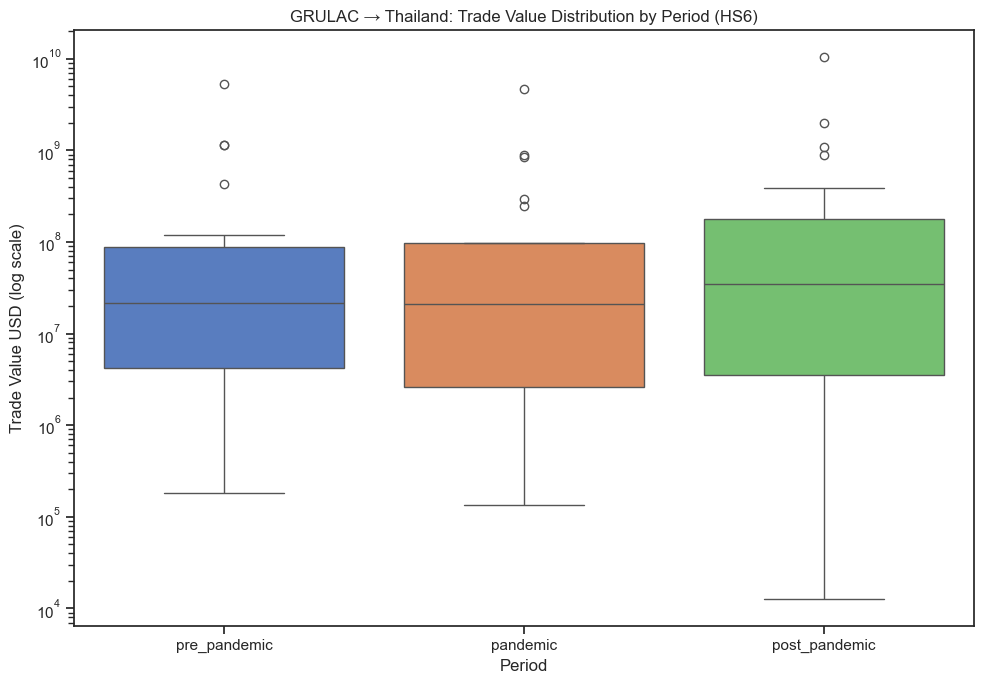

In [44]:
# Chart: Boxplot - Trade value distribution by period (pre/pandemic/post)
bx_trade_period = (
    df_pandemic.groupby(["reportername", "period"])["trade_value_usd"]
    .sum()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 7))
sns.boxplot(
    data=bx_trade_period,
    x="period",
    y="trade_value_usd",
    ax=ax,
    hue="period",
    legend=False,
    dodge=False,
)
ax.set_yscale("log")
ax.set_title(
    f"GRULAC → {partner_to_evaluate}: Trade Value Distribution by Period (HS6)"
)
ax.set_ylabel("Trade Value USD (log scale)")
ax.set_xlabel("Period")

plt.tight_layout()
plt.show()


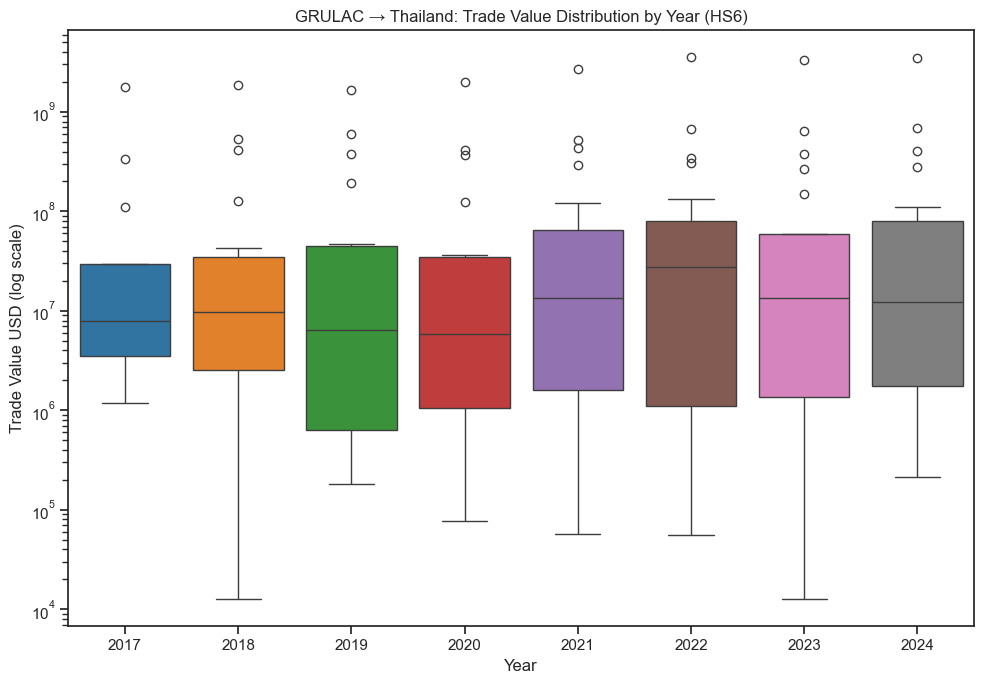

In [45]:
# Chart: Boxplot - Trade value distribution by year
bx_trade_year = (
    df_pandemic.groupby(["reportername", "year"])["trade_value_usd"].sum().reset_index()
)

fig, ax = plt.subplots(figsize=(10, 7))
sns.boxplot(
    data=bx_trade_year,
    x="year",
    y="trade_value_usd",
    ax=ax,
    hue="year",
    palette="tab10",
    legend=False,
)
ax.set_yscale("log")
ax.set_title(f"GRULAC → {partner_to_evaluate}: Trade Value Distribution by Year (HS6)")
ax.set_ylabel("Trade Value USD (log scale)")
ax.set_xlabel("Year")

plt.tight_layout()
plt.show()


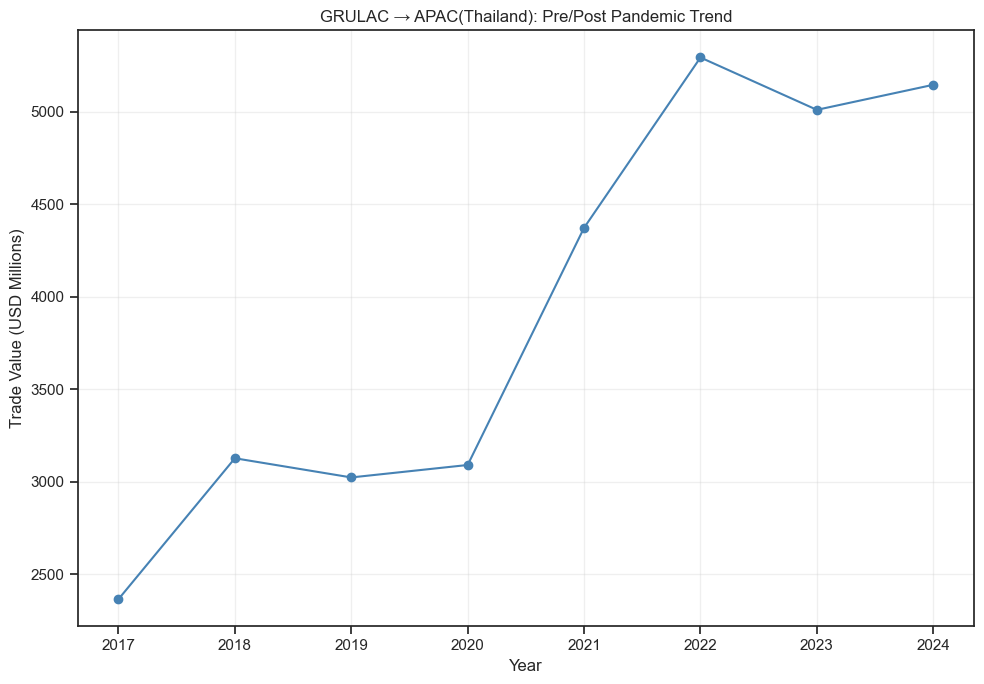

In [46]:
# Chart: Line - Aggregate trade trend, GRULAC → Thailand (all reporters combined)
trend = pre_post_pandemic_chart.sum(axis=0) / USD_MILLIONS  # USD millions

fig, ax = plt.subplots(figsize=(10, 7))
trend.plot(ax=ax, marker="o", color="steelblue")
ax.set_title(f"GRULAC → APAC({partner_to_evaluate}): Pre/Post Pandemic Trend")
ax.set_xlabel("Year")
ax.set_ylabel("Trade Value (USD Millions)")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


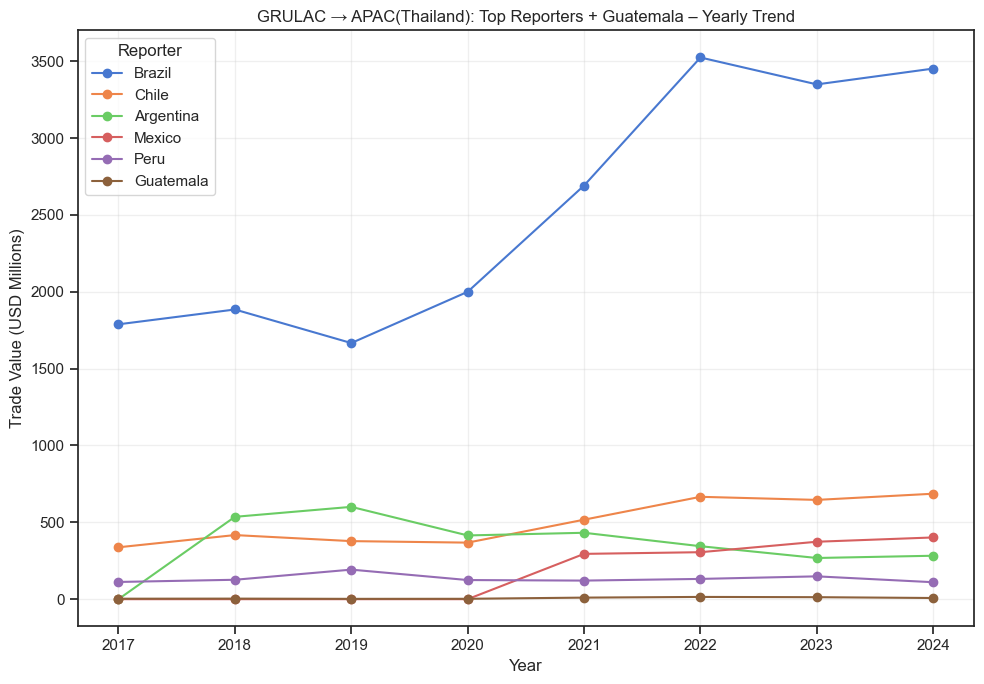

In [47]:
# Chart: Line - Yearly trade trends, top 5 reporters + Guatemala → Thailand
top5 = pre_post_pandemic_chart.sum(axis=1).nlargest(5).index.tolist()
if reporter_to_evaluate not in top5:
    top5.append(reporter_to_evaluate)

fig, ax = plt.subplots(figsize=(10, 7))
(pre_post_pandemic_chart.loc[top5] / USD_MILLIONS).T.plot(ax=ax, marker="o")
ax.set_title(
    f"GRULAC → APAC({partner_to_evaluate}): Top Reporters + Guatemala – Yearly Trend"
)
ax.set_xlabel("Year")
ax.set_ylabel("Trade Value (USD Millions)")
ax.legend(title="Reporter")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


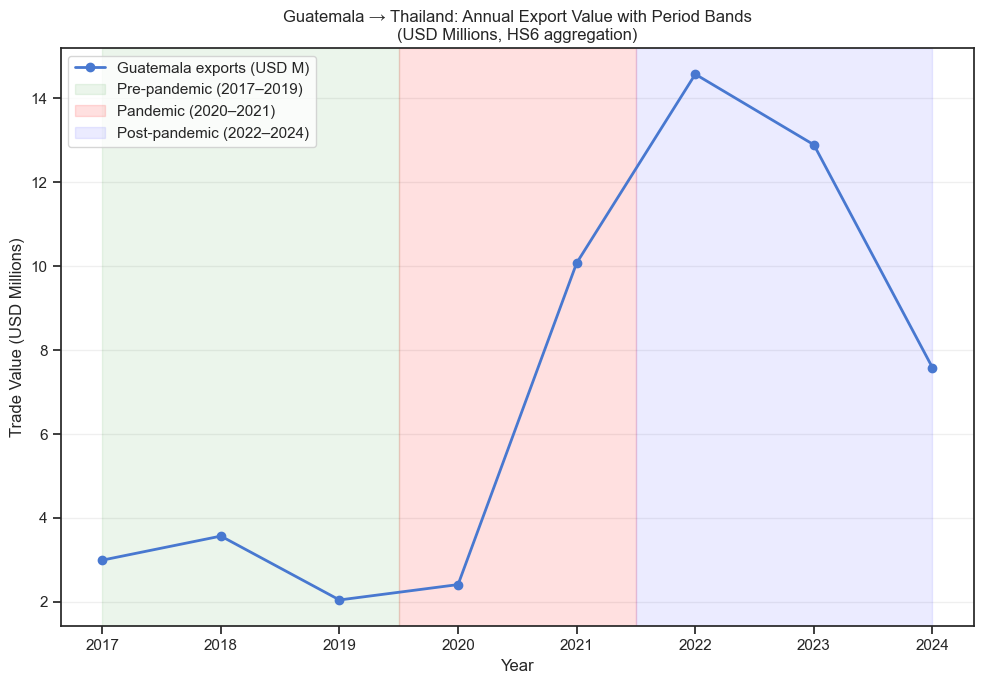

In [48]:
# Chart: Line - Guatemala annual exports to Thailand with period bands (HS6 Level)
gtm_yearly = (
    df_pandemic[df_pandemic["reportername"] == reporter_to_evaluate]
    .groupby("year")["trade_value_usd"]
    .sum()
    .div(USD_MILLIONS)
)

fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(
    gtm_yearly.index,
    gtm_yearly.values,
    marker="o",
    linewidth=2,
    label="Guatemala exports (USD M)",
)

ax.axvspan(
    gtm_yearly.index.min(),
    2019.5,
    alpha=0.08,
    color="green",
    label="Pre-pandemic (2017–2019)",
)
ax.axvspan(2019.5, 2021.5, alpha=0.12, color="red", label="Pandemic (2020–2021)")
ax.axvspan(
    2021.5,
    gtm_yearly.index.max(),
    alpha=0.08,
    color="blue",
    label="Post-pandemic (2022–2024)",
)

ax.set_title(
    "Guatemala → Thailand: Annual Export Value with Period Bands\n"
    "(USD Millions, HS6 aggregation)"
)
ax.set_xlabel("Year")
ax.set_ylabel("Trade Value (USD Millions)")
ax.set_xticks(gtm_yearly.index)
ax.legend()
plt.tight_layout()

plt.grid(axis="y", alpha=0.3)
plt.show()


In [ ]:
# Metric 1: Pandemic impact per reporter as the percentage change between pandemic and pre-pandemic periods
impact = (
    (df_period["pandemic"] - df_period["pre_pandemic"]) / df_period["pre_pandemic"]
).dropna()

impact


reportername
Argentina            -0.25
Bahamas, The           inf
Barbados             10.13
Belize               -0.63
Bolivia              -0.59
Brazil               -0.12
Chile                -0.22
Colombia             -0.29
Costa Rica            0.14
Cuba                 -0.31
Dominican Republic   -0.02
Ecuador               3.46
El Salvador           1.56
Guatemala             0.45
Guyana                4.32
Honduras             -0.60
Jamaica               0.43
Mexico                 inf
Nicaragua            -0.01
Panama               -0.21
Paraguay              0.00
Peru                 -0.43
Uruguay              -0.20
dtype: float64

In [50]:
# Metric 2: Post-pandemic recovery index per reporter as the ratio of post-pandemic to pre-pandemic trade
recovery = (df_period["post_pandemic"] / df_period["pre_pandemic"]).dropna()

recovery


reportername
Argentina             0.79
Bahamas, The           inf
Barbados              7.66
Belize                0.03
Bolivia               0.81
Brazil                1.93
Chile                 1.76
Colombia              1.18
Costa Rica            1.35
Cuba                  0.05
Dominican Republic    0.79
Ecuador               6.82
El Salvador           1.99
Guatemala             4.07
Guyana               15.51
Honduras              0.51
Jamaica               0.20
Mexico                 inf
Nicaragua             0.86
Panama                0.98
Paraguay              1.24
Peru                  0.91
Uruguay               1.72
dtype: float64

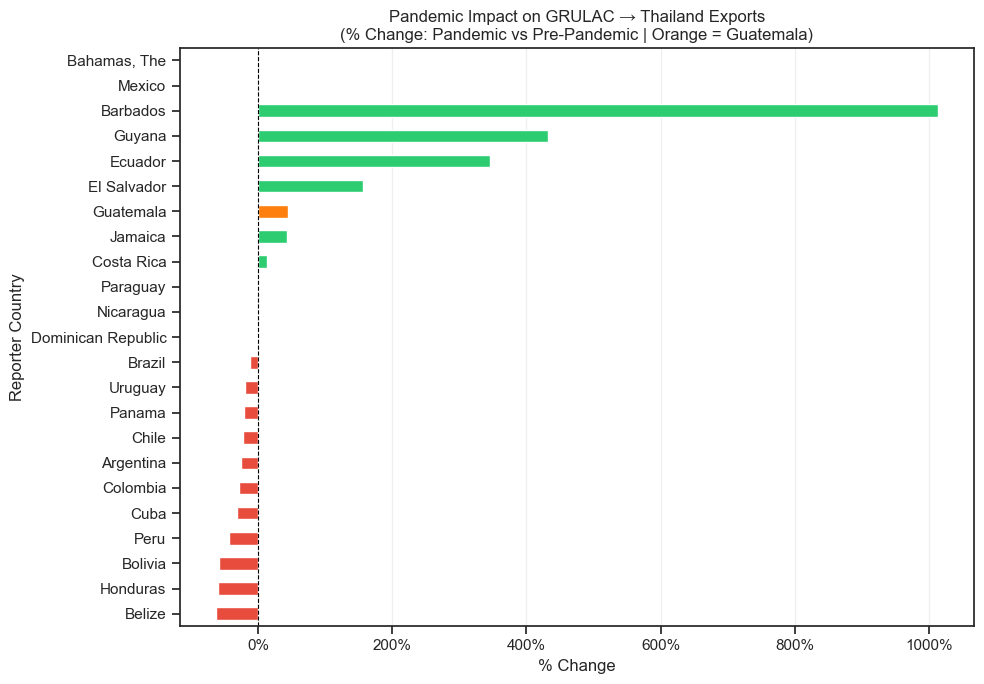

In [ ]:
# Chart: Horizontal bar - Pandemic impact per reporter (% change: pandemic vs pre-pandemic)
# Positive = growth during pandemic; Negative = contraction
impact_sorted = impact.sort_values()
bar_colors = [
    GTM_HIGHLIGHT
    if idx == reporter_to_evaluate
    else ("#e74c3c" if v < 0 else "#2ecc71")
    for idx, v in impact_sorted.items()
]

fig, ax = plt.subplots(figsize=(10, 7))
impact_sorted.plot(kind="barh", ax=ax, color=bar_colors)
ax.axvline(x=0, color="black", linewidth=0.8, linestyle="--")
ax.set_title(
    "Pandemic Impact on GRULAC → Thailand Exports\n"
    "(% Change: Pandemic vs Pre-Pandemic | Orange = Guatemala)"
)
ax.set_xlabel("% Change")
ax.set_ylabel("Reporter Country")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
plt.tight_layout()

plt.grid(axis="x", alpha=0.3)
plt.show()


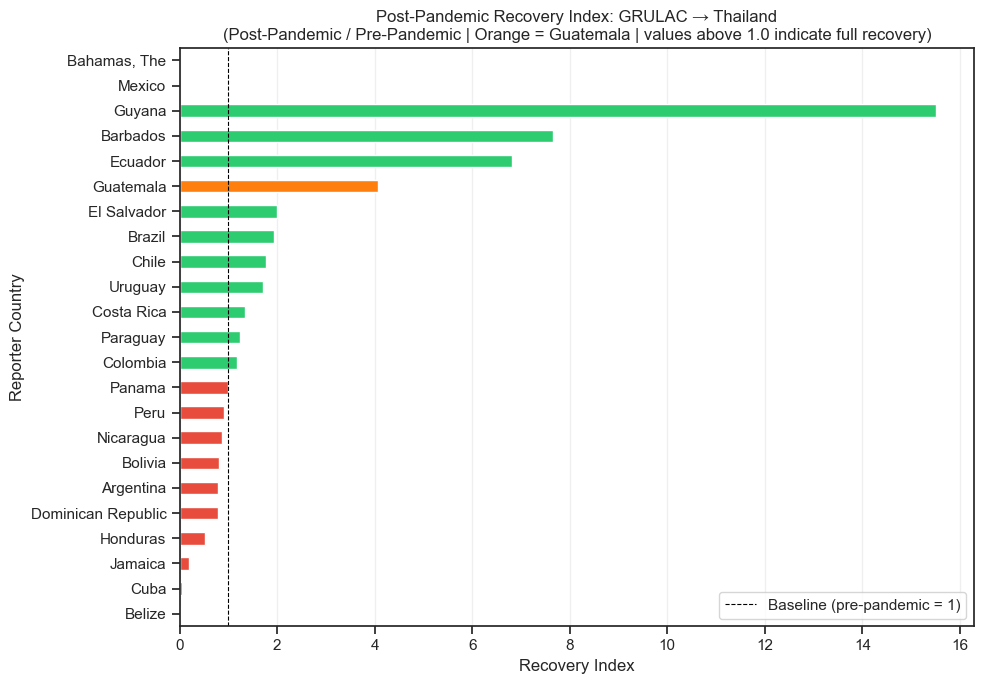

In [ ]:
# Chart: Horizontal bar - Post-pandemic recovery index per reporter (post_pandemic / pre_pandemic)
# >1 = surpassed pre-pandemic levels; <1 = still below pre-pandemic levels
recovery_sorted = recovery.sort_values()
bar_colors_rec = [
    GTM_HIGHLIGHT
    if idx == reporter_to_evaluate
    else ("#e74c3c" if v < 1 else "#2ecc71")
    for idx, v in recovery_sorted.items()
]

fig, ax = plt.subplots(figsize=(10, 7))
recovery_sorted.plot(kind="barh", ax=ax, color=bar_colors_rec)
ax.axvline(
    x=1.0,
    color="black",
    linewidth=0.8,
    linestyle="--",
    label="Baseline (pre-pandemic = 1)",
)
ax.set_title(
    "Post-Pandemic Recovery Index: GRULAC → Thailand\n"
    "(Post-Pandemic / Pre-Pandemic | Orange = Guatemala | values above 1.0 indicate full recovery)"
)
ax.set_xlabel("Recovery Index")
ax.set_ylabel("Reporter Country")
ax.legend()
plt.tight_layout()

plt.grid(axis="x", alpha=0.3)
plt.show()


### Guatemala in Context: Comparative Positioning

The following charts position Guatemala against other GRULAC reporters:
trade volume per period for the top performers, and the joint distribution
of pandemic impact and recovery across all reporters.


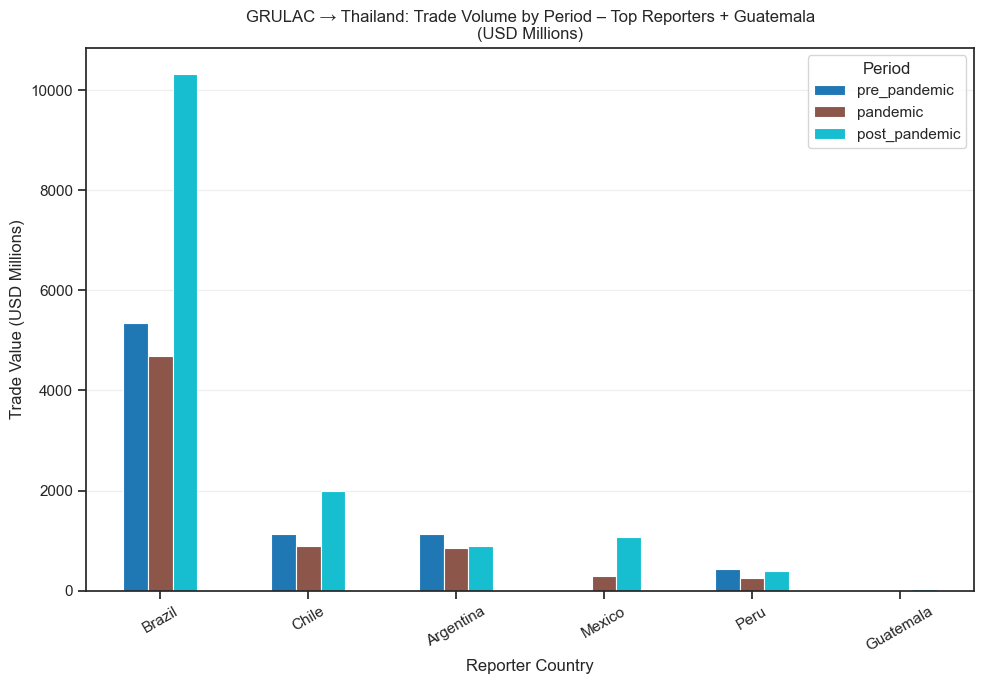

In [53]:
# Chart: Grouped bar - Trade volume by period for top 5 reporters + Guatemala
top_reporters = df_period.sum(axis=1).nlargest(5).index.tolist()
if reporter_to_evaluate not in top_reporters:
    top_reporters.append(reporter_to_evaluate)

# Convert to USD millions for readability
df_top_period = df_period.loc[top_reporters] / USD_MILLIONS

ax = df_top_period.plot(
    kind="bar",
    figsize=(10, 7),
    colormap="tab10",
    edgecolor="white",
    linewidth=0.8,
)
ax.set_title(
    "GRULAC → Thailand: Trade Volume by Period – Top Reporters + Guatemala\n(USD Millions)"
)
ax.set_xlabel("Reporter Country")
ax.set_ylabel("Trade Value (USD Millions)")
ax.tick_params(axis="x", rotation=30)
ax.legend(title="Period")
plt.tight_layout()

plt.grid(axis="y", alpha=0.3)
plt.show()


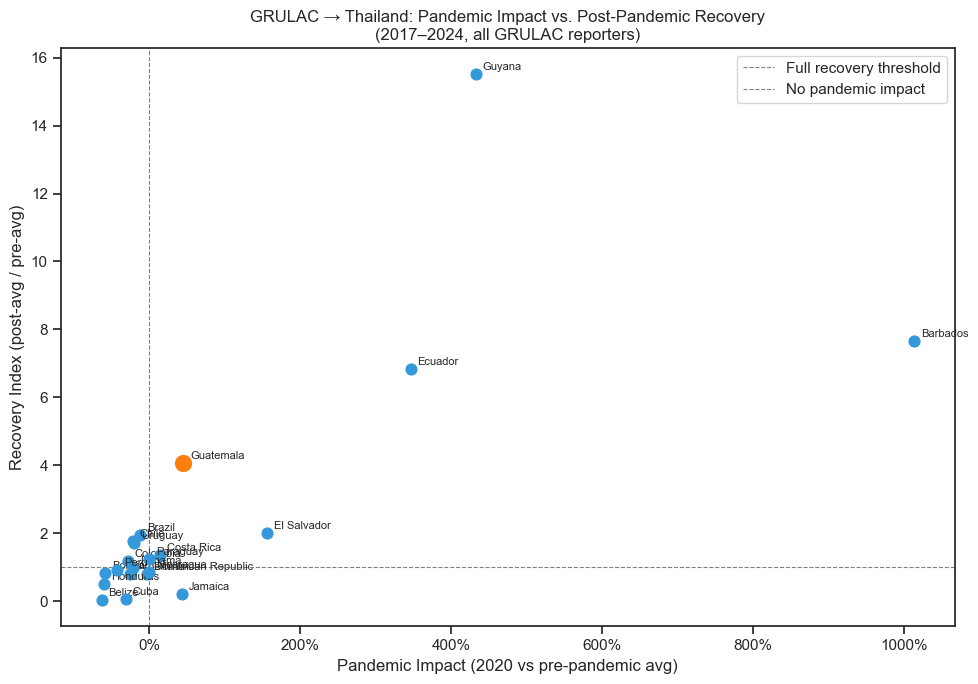

In [60]:
# Chart: Scatter - Pandemic impact (x) vs. recovery strength (y) for all GRULAC reporters
df_scatter = pd.DataFrame({"impact": impact, "recovery": recovery}).dropna()

fig, ax = plt.subplots(figsize=(10, 7))
for country, row in df_scatter.iterrows():
    color = GTM_HIGHLIGHT if country == reporter_to_evaluate else "#3498db"
    size = 130 if country == reporter_to_evaluate else 60
    ax.scatter(row["impact"], row["recovery"], color=color, s=size, zorder=3)
    ax.annotate(
        country,
        (row["impact"], row["recovery"]),
        fontsize=8,
        textcoords="offset points",
        xytext=(5, 3),
    )

ax.axhline(
    y=1.0, color="gray", linestyle="--", linewidth=0.8, label="Full recovery threshold"
)
ax.axvline(
    x=0.0, color="gray", linestyle="--", linewidth=0.8, label="No pandemic impact"
)
ax.set_xlabel("Pandemic Impact (2020 vs pre-pandemic avg)")
ax.set_ylabel("Recovery Index (post-avg / pre-avg)")
ax.set_title(
    "GRULAC → Thailand: Pandemic Impact vs. Post-Pandemic Recovery\n"
    "(2017–2024, all GRULAC reporters)"
)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.legend()

plt.tight_layout()
plt.show()


## 9. Summary


In [55]:
# Guatemala-specific summary: pandemic impact and recovery position relative to all GRULAC reporters
gtm_impact = impact.get(reporter_to_evaluate)
gtm_recovery = recovery.get(reporter_to_evaluate)

n_impact = impact.count()
n_recovery = recovery.count()

# Rank: #1 = worst impact / strongest recovery
impact_rank = int((impact < gtm_impact).sum()) + 1
recovery_rank = int((recovery > gtm_recovery).sum()) + 1

print("Guatemala - Pre/Post Pandemic Summary")
print("-" * 45)
print(
    f"  Pandemic impact:     {gtm_impact:+.1%}  (rank #{impact_rank} of {n_impact}; #1 = most affected)"
)
print(
    f"  Recovery index:      {gtm_recovery:.2f}x  (rank #{recovery_rank} of {n_recovery}; #1 = strongest recovery)"
)
print(f"  Recovered to pre-pandemic level: {'Yes' if gtm_recovery >= 1.0 else 'No'}")


Guatemala - Pre/Post Pandemic Summary
---------------------------------------------
  Pandemic impact:     +45.1%  (rank #17 of 23; #1 = most affected)
  Recovery index:      4.07x  (rank #6 of 23; #1 = strongest recovery)
  Recovered to pre-pandemic level: Yes


In [56]:
# End: Calculates and prints the total notebook execution time
end_time_code = time.perf_counter()
run_time_code = end_time_code - start_time_code
print(
    f"\n-- Total execution time: {run_time_code:.2f} seconds -> {run_time_code / 60:.2f} minutes --"
)



-- Total execution time: 3.96 seconds -> 0.07 minutes --


In [57]:
# Stops execution to prevent running additional exploratory cells below
raise SystemExit("Notebook execution stopped here intentionally")


SystemExit: Notebook execution stopped here intentionally

/Users/danielval/Code/Repositories/Portfolio/lab-01-data-analytics-pipeline/.conda/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3709: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


---

## Appendix: Scratch / Exploratory Cells


In [ ]:
# Competition pivot filtered by focus products
pivot_competition.loc[
    pivot_competition.index.get_level_values("productcode").isin(focus_products)
]


In [ ]:
title_txt = f"Ranking: GRULAC vs. {reporter_to_evaluate} GTM participation"

# Print results
print_title(title_txt)

top_grulac_product_global[top_grulac_product_global["ranking_GTM"] == 1].sort_values(
    "ranking"
).head(25).reset_index(drop=True)


In [ ]:
# Global ranking view, productname contains pattern search
product_name = ["coffee", "sugar"]
pattern = "|".join(product_name)
top_grulac_product_global[
    top_grulac_product_global["productdescription"].str.contains(
        pattern, case=False, na=False
    )
]


In [ ]:
def single_product_evaluation(product_code):
    """Evaluate a single product's trade competition among GRULAC reporters for the evaluated partner.

    Filters APAC micro data for the given product and current partner, then ranks all GRULAC reporters by total trade value.

    Note:
        Uses module-level variables: df_apac_micro, partner_to_evaluate.

    Args:
        product_code (str): HS6 product code to evaluate (e.g., '090111').

    Returns:
        pd.DataFrame: Reporter-level trade summary sorted by trade value descending,
            with columns 'reportername' and 'total_trade_usd'.
    """
    product_evaluation = df_apac_micro.query(
        "partnername == @partner_to_evaluate and productcode == @product_code"
    )

    product_description = product_evaluation["productdescription"].iloc[0]

    product_evaluation = (
        (product_evaluation)
        .groupby("reportername", as_index=False)
        .agg(total_trade_usd=("trade_value_usd", "sum"))
        .sort_values("total_trade_usd", ascending=False)
        .reset_index(drop=True)
    )

    # Print results
    print(f"{product_code}: {product_description}")
    print(f"Total trade value: {product_evaluation['total_trade_usd'].sum():,.2f}")

    return product_evaluation


In [ ]:
# Display a single-product competition query (HS6 level)
product_code = "090111"  # HS6 code for coffee
single_product_evaluation(product_code)


In [ ]:
# Display a single-product competition query (HS6 level)
product_code = "170114"  # HS6 code for Sugars
single_product_evaluation(product_code)


In [ ]:
# Display a single-product competition query (HS6 level)
product_code = "760200"  # HS6 code for Aluminium
single_product_evaluation(product_code)


In [ ]:
# E.g.,: If needed for Helper Functions - (Modify Note in docstring)
# def single_product_evaluation(product_code, partner=None, df=None):
#     if df is None:
#         df = df_apac_micro
#     if partner is None:
#         partner = partner_to_evaluate


In [ ]:
# E.g.,: If needed to evaluate the table Reporter Focused
# Global GRULAC product ranking → APAC (Evaluated Partner) (HS6 Level) - Reporter Independent
# Aggregates trade value across all GRULAC reporters and identifies the top reporter per product

###
#
# Code
#
###

###--- Ranking Map Evaluated Reporter dependent
# # Ranking: GRULAC (Global) vs. Guatemala - Exports to APAC (Evaluated Partner) (HS6 Level)
# # Maps Guatemala's reporter-specific ranking onto the global product ranking
# grulac_ranking_map = top_grulac_partner_apac_reporter_hs6.set_index("productcode")[
#     "ranking"
# ].to_dict()
###---
